# Ultimate YOLO11 tracking comparison

CPU-only, no-training study on five complete clips: three football videos,
MI6, and Joker. Four methods share one YOLO11n detection cache per clip:
OC-SORT; Deep OC-SORT; Deep OC-SORT with OSNet weight 1.0; and Deep OC-SORT
with guarded hard cuts and selective OSNet identity recovery.

The first sections build the first four clips, then add Joker and the
fourth column. The final section audits all 20 outputs and the annotated
SportsMOT calibration. Videos are shown in the separate web gallery.

## Final checkpoint and interpretation

All 20 full-duration annotated videos were rebuilt and checked against their
source frame count, FPS, and resolution. See outputs/reports/video_gallery.html.

On one annotated SportsMOT training sequence, tuned Deep OC-SORT improved
from HOTA 38.74 / IDF1 33.50 / 381 ID switches to HOTA 50.52 / IDF1 50.39 /
169 switches. This is calibration, not independent test performance.

The five custom clips have no identity ground truth. Created IDs, detected
cuts, and accepted appearance matches there are diagnostics, not measured
HOTA, IDF1, true switches, or verified ReID accuracy. The full diagnosis is
in docs/TRACKING_DIAGNOSIS.md.

## Context & Methods

### Key assumptions

- Execution is CPU-only.
- YOLO11n uses pretrained COCO weights and detects only class `person`.
- Every source frame is processed; no sampling or frame limit is allowed.
- A cache is valid only if its fingerprint, frame count, width, and height match
  the corresponding source.
- Custom videos have no identity ground truth. Detector and runtime diagnostics
  are observable, but tracking accuracy metrics such as HOTA and IDF1 require
  annotations and will not be fabricated.

## Setup

In [1]:
from __future__ import annotations

import json
import platform
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from scenecut_tracking.config import load_config
from scenecut_tracking.detection_cache import DetectionCache, build_detection_cache
from scenecut_tracking.detector import YoloPersonDetector
from scenecut_tracking.frame_source import read_source_metadata

CONFIG_PATH = PROJECT_ROOT / "configs" / "ultimate_cpu.yaml"
CONFIG = load_config(CONFIG_PATH)
VIDEO_PATHS = {
    name: PROJECT_ROOT / relative_path
    for name, relative_path in CONFIG["experiment"]["videos"].items()
}
CACHE_ROOT = PROJECT_ROOT / CONFIG["experiment"]["detection_cache_root"]
FIGURE_ROOT = PROJECT_ROOT / "outputs" / "comparisons" / "figures"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

REBUILD_DETECTION_CACHES = False
np.random.seed(42)

COLORS = {
    "football-1": "#2563EB",
    "football-2": "#D97706",
    "football-3": "#7C3AED",
    "MI6": "#0F766E",
}
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.alpha": 0.22,
    "font.size": 11,
})

print(f"Project: {PROJECT_ROOT}")
print(f"Config: {CONFIG_PATH}")
print(f"Python: {platform.python_version()}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {CONFIG['experiment']['device']}")
print(f"Process all frames: {CONFIG['experiment']['process_all_frames']}")

Project: D:\Bunker\BaseCamp\ComputerVision\SceneCut Aware tracking
Config: D:\Bunker\BaseCamp\ComputerVision\SceneCut Aware tracking\configs\ultimate_cpu.yaml
Python: 3.12.12
PyTorch: 2.14.0+cpu
Device: cpu
Process all frames: True


## Data — validate the first four canonical inputs

In [2]:
input_rows = []
for video_name, video_path in VIDEO_PATHS.items():
    assert video_path.is_file(), f"Missing input video: {video_path}"
    metadata = read_source_metadata(video_path)
    input_rows.append({
        "video": video_name,
        "frames": metadata.frame_count,
        "fps": metadata.fps,
        "duration_seconds": metadata.frame_count / metadata.fps,
        "resolution": f"{metadata.width}x{metadata.height}",
        "fingerprint": metadata.fingerprint[:12],
        "path": str(video_path.relative_to(PROJECT_ROOT)),
    })

input_summary = pd.DataFrame(input_rows)
assert {"football-1", "football-2", "football-3", "MI6"}.issubset(set(input_summary["video"]))
assert (input_summary["frames"] > 0).all()
assert (input_summary["fps"] > 0).all()
display(input_summary.style.format({"fps": "{:.2f}", "duration_seconds": "{:.2f}"}))

,video,frames,fps,duration_seconds,resolution,fingerprint,path
0,football-1,1122,30.00,37.40,1232x642,f56949b3f1f1,data\videos\desktop_clips\football-1.mp4
1,football-2,722,30.00,24.07,1264x650,892f9f6105df,data\videos\desktop_clips\football-2.mp4
2,football-3,842,30.00,28.07,1274x718,19ca8d548558,data\videos\desktop_clips\football-3.mp4
3,MI6,918,30.00,30.60,1300x540,bcb65b9b1f61,data\MI6.mp4
4,Joker,551,30.00,18.37,1282x720,09a8b72fe84b,data\Joker.mp4


## Step 3 — shared YOLO11 detection caches

In [3]:
detector = YoloPersonDetector(CONFIG["detector"], PROJECT_ROOT)
cache_results: dict[str, dict] = {}

def build_or_validate_cache(video_name: str) -> dict:
    video_path = VIDEO_PATHS[video_name]
    cache_path = CACHE_ROOT / f"{video_name}_yolo11n_cpu.npz"

    if cache_path.exists() and not REBUILD_DETECTION_CACHES:
        cache = DetectionCache.load(cache_path)
        action = "validated existing cache"
    else:
        print(f"Running pretrained YOLO11n on every frame of {video_name}...")
        cache = build_detection_cache(video_path, detector, CONFIG["detector"])
        cache.save(cache_path)
        action = "built new cache"

    source_metadata = cache.validate_source(video_path)
    cached_video = cache.metadata["video"]
    runtime = cache.metadata["runtime"]
    assert cached_video["frame_count"] == source_metadata.frame_count
    assert cached_video["width"] == source_metadata.width
    assert cached_video["height"] == source_metadata.height
    assert cache.metadata["detector"]["model"] == "yolo11n.pt"
    assert cache.metadata["detector"]["device"] == "cpu"

    result = {
        "video": video_name,
        "status": action,
        "source_frames": source_metadata.frame_count,
        "cache_frames": cached_video["frame_count"],
        "detection_rows": runtime["detection_rows"],
        "elapsed_seconds": runtime["elapsed_seconds"],
        "detector_fps": runtime["processing_fps"],
        "mean_detections_per_frame": runtime["detection_rows"] / source_metadata.frame_count,
        "cache_path": str(cache_path.relative_to(PROJECT_ROOT)),
    }
    cache_results[video_name] = result
    return result

In [4]:
football_1_cache = build_or_validate_cache('football-1')
football_1_cache

{'video': 'football-1',
 'status': 'validated existing cache',
 'source_frames': 1122,
 'cache_frames': 1122,
 'detection_rows': 8364,
 'elapsed_seconds': 115.66794189999928,
 'detector_fps': 9.700181239241077,
 'mean_detections_per_frame': 7.454545454545454,
 'cache_path': 'outputs\\detection_cache\\football-1_yolo11n_cpu.npz'}

In [5]:
football_2_cache = build_or_validate_cache('football-2')
football_2_cache

{'video': 'football-2',
 'status': 'validated existing cache',
 'source_frames': 722,
 'cache_frames': 722,
 'detection_rows': 6179,
 'elapsed_seconds': 58.34350899999845,
 'detector_fps': 12.37498416490546,
 'mean_detections_per_frame': 8.558171745152354,
 'cache_path': 'outputs\\detection_cache\\football-2_yolo11n_cpu.npz'}

In [6]:
football_3_cache = build_or_validate_cache('football-3')
football_3_cache

{'video': 'football-3',
 'status': 'validated existing cache',
 'source_frames': 842,
 'cache_frames': 842,
 'detection_rows': 13947,
 'elapsed_seconds': 127.40125100000296,
 'detector_fps': 6.609040283285605,
 'mean_detections_per_frame': 16.56413301662708,
 'cache_path': 'outputs\\detection_cache\\football-3_yolo11n_cpu.npz'}

In [7]:
mi6_cache = build_or_validate_cache('MI6')
mi6_cache

{'video': 'MI6',
 'status': 'validated existing cache',
 'source_frames': 918,
 'cache_frames': 918,
 'detection_rows': 4203,
 'elapsed_seconds': 58.17468309999094,
 'detector_fps': 15.780060175353888,
 'mean_detections_per_frame': 4.578431372549019,
 'cache_path': 'outputs\\detection_cache\\MI6_yolo11n_cpu.npz'}

## Results — detection-cache audit

In [8]:
detection_summary = pd.DataFrame(cache_results.values()).sort_values("video").reset_index(drop=True)
assert len(detection_summary) == 4
assert (detection_summary["source_frames"] == detection_summary["cache_frames"]).all()
assert (detection_summary["detection_rows"] > 0).all()
assert (detection_summary["detector_fps"] > 0).all()

display(
    detection_summary.style.format({
        "elapsed_seconds": "{:.2f}",
        "detector_fps": "{:.2f}",
        "mean_detections_per_frame": "{:.2f}",
    })
)
print("PASS: all four caches cover every source frame and match source provenance.")

,video,status,source_frames,cache_frames,detection_rows,elapsed_seconds,detector_fps,mean_detections_per_frame,cache_path
0,MI6,validated existing cache,918,918,4203,58.17,15.78,4.58,outputs\detection_cache\MI6_yolo11n_cpu.npz
1,football-1,validated existing cache,1122,1122,8364,115.67,9.70,7.45,outputs\detection_cache\football-1_yolo11n_cpu.npz
2,football-2,validated existing cache,722,722,6179,58.34,12.37,8.56,outputs\detection_cache\football-2_yolo11n_cpu.npz
3,football-3,validated existing cache,842,842,13947,127.40,6.61,16.56,outputs\detection_cache\football-3_yolo11n_cpu.npz


PASS: all four caches cover every source frame and match source provenance.


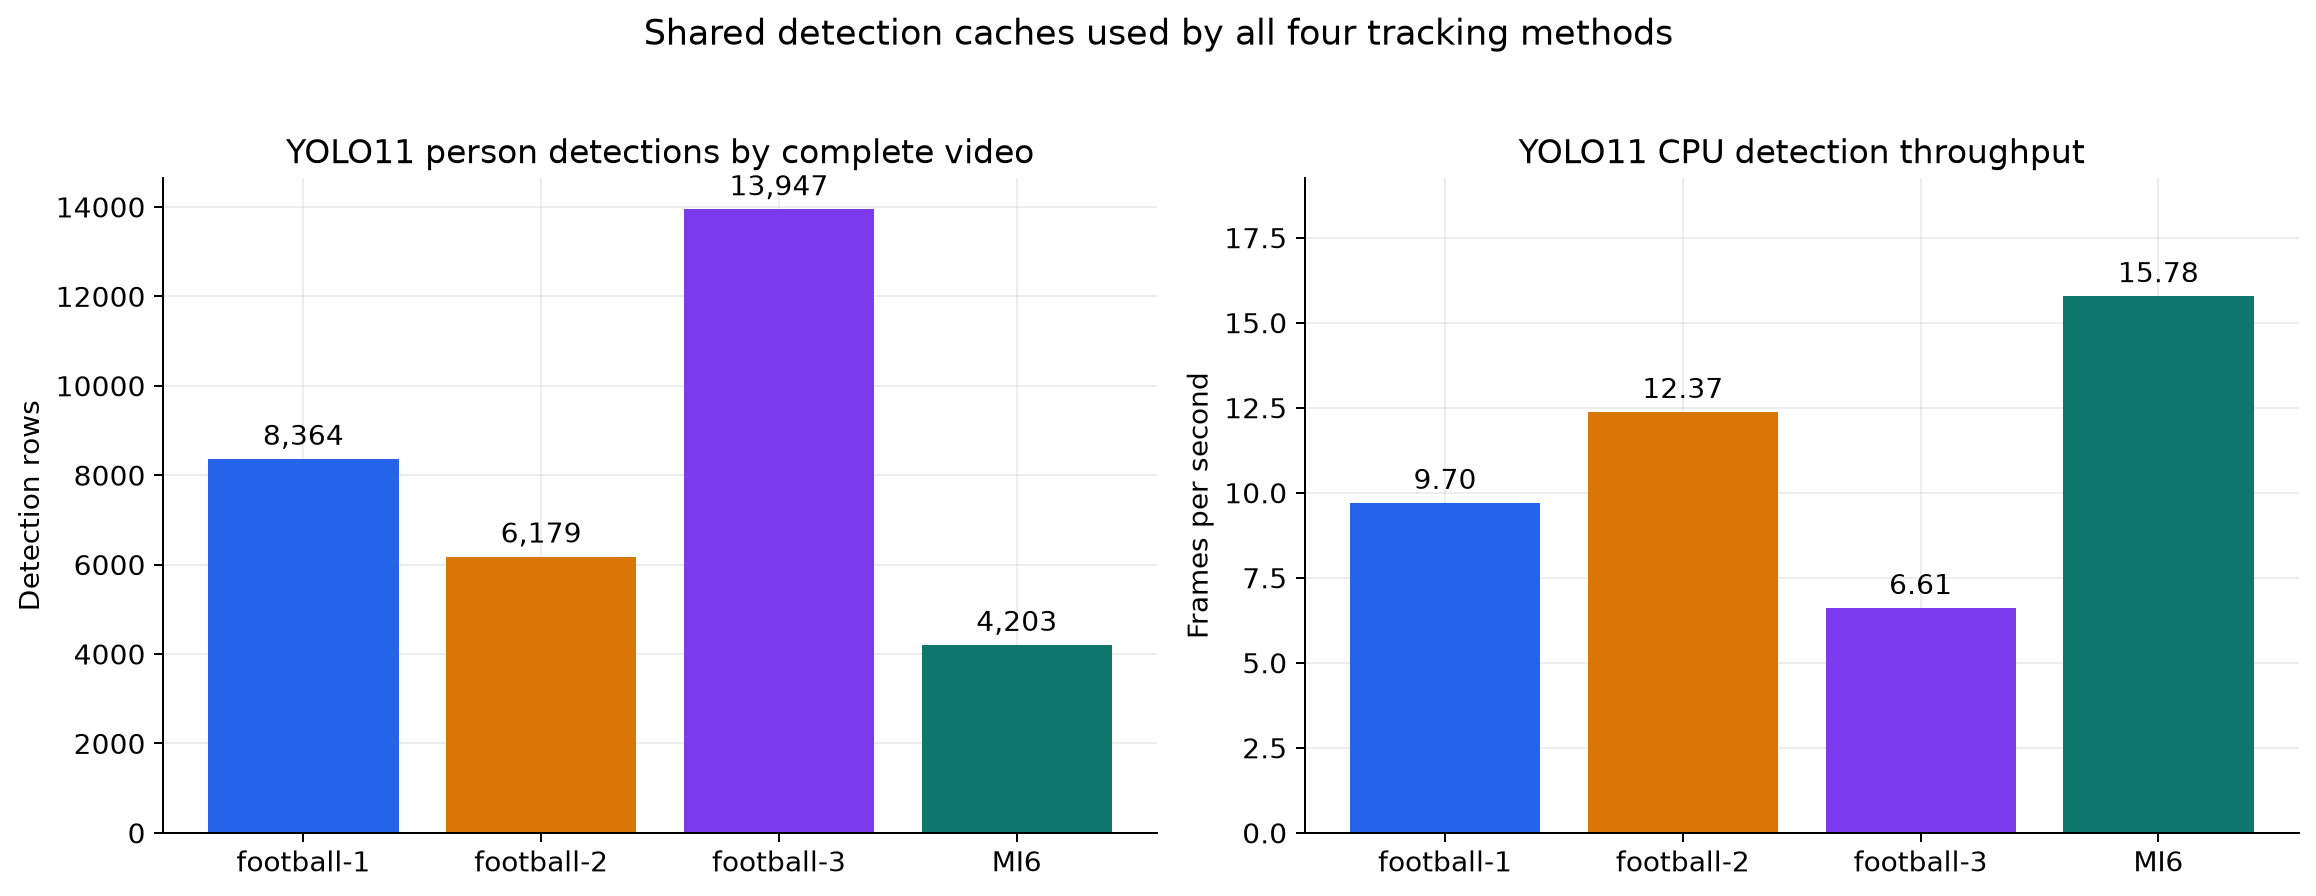

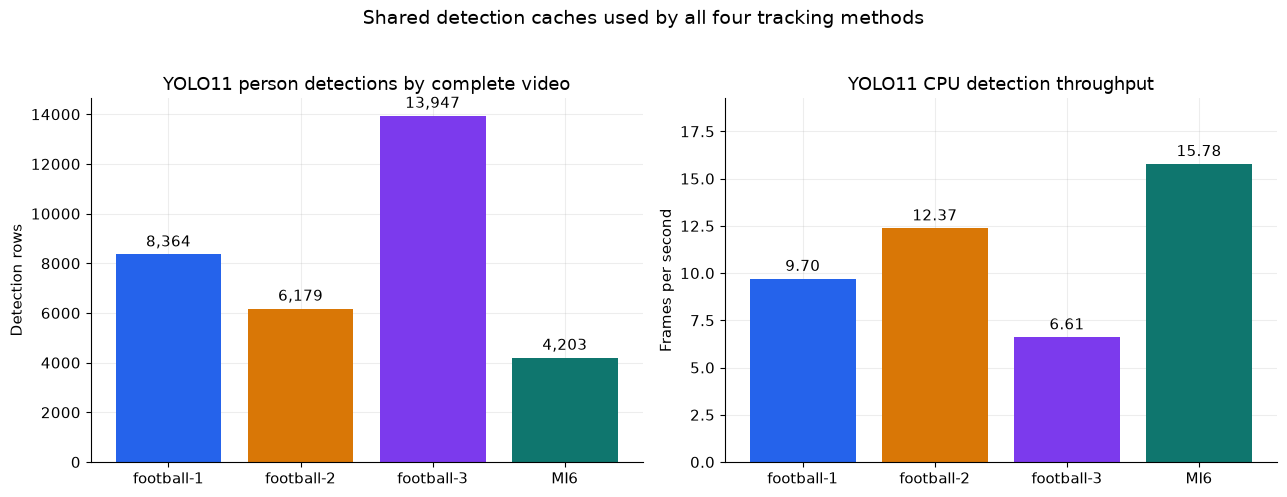

Saved figure: outputs\comparisons\figures\step3_yolo11_detection_cache_summary.png


In [9]:
ordered = detection_summary.set_index("video").loc[["football-1", "football-2", "football-3", "MI6"]]
figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))
bar_colors = [COLORS[name] for name in ordered.index]

detection_bars = axes[0].bar(ordered.index, ordered["detection_rows"], color=bar_colors)
axes[0].set_title("YOLO11 person detections by complete video")
axes[0].set_ylabel("Detection rows")
axes[0].set_xlabel("")
axes[0].bar_label(detection_bars, fmt="{:,.0f}", padding=3)

fps_bars = axes[1].bar(ordered.index, ordered["detector_fps"], color=bar_colors)
axes[1].set_title("YOLO11 CPU detection throughput")
axes[1].set_ylabel("Frames per second")
axes[1].set_xlabel("")
axes[1].bar_label(fps_bars, fmt="%.2f", padding=3)
axes[1].set_ylim(0, max(ordered["detector_fps"]) * 1.22)

figure.suptitle("Shared detection caches used by all four tracking methods", fontsize=14, y=1.03)
figure.tight_layout()
figure_path = FIGURE_ROOT / "step3_yolo11_detection_cache_summary.png"
figure.savefig(figure_path, dpi=180, bbox_inches="tight", facecolor="white")
display(Image(filename=str(figure_path)))
plt.show()
print(f"Saved figure: {figure_path.relative_to(PROJECT_ROOT)}")

## Takeaways — shared detection caches

- The first four caches cover all 3,604 frames. Joker is added later.
- football-3 has 13,947 low-threshold person proposals; proposal count is
  not detection accuracy.
- Identical cached detections per clip control the tracker comparison.
- No tracker threshold can repair a missing or badly placed YOLO box.

## Step 4 — YOLO11 + OC-SORT baseline

OC-SORT is the motion-only baseline. YOLO11 provides person boxes; OC-SORT
uses Kalman motion prediction, observation-centric updates, and IoU-based
association to assign track IDs. Appearance embeddings and scene-cut logic
are disabled in this stage.

Each video is processed completely from its immutable Step 3 cache.

In [10]:
import shutil

from scenecut_tracking.runner import run_video
from scenecut_tracking.runtime import write_json
from scenecut_tracking.video_export import make_browser_video

EXPERIMENT_ROOT = PROJECT_ROOT / CONFIG["experiment"]["output_root"]
ocsort_results: dict[str, dict] = {}

def inspect_video(path: Path) -> dict:
    capture = cv2.VideoCapture(str(path))
    if not capture.isOpened():
        raise RuntimeError(f"Cannot open video: {path}")
    frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(capture.get(cv2.CAP_PROP_FPS))
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    capture.release()
    if fps <= 0:
        raise AssertionError(f"Invalid FPS for {path}: {fps}")
    return {
        "frames": frames,
        "fps": fps,
        "duration_seconds": frames / fps,
        "width": width,
        "height": height,
    }

def standardize_ocsort_artifacts(output_dir: Path, metrics: dict) -> dict:
    generated_video = output_dir / "annotated_baseline.mp4"
    standard_video = output_dir / "annotated.mp4"
    browser_video = output_dir / "annotated_h264.mp4"

    if generated_video.exists():
        if standard_video.exists():
            standard_video.unlink()
        generated_video.replace(standard_video)
    if not standard_video.exists():
        raise FileNotFoundError(standard_video)
    if not browser_video.exists():
        make_browser_video(standard_video, browser_video)

    plots_dir = output_dir / "plots"
    plots_dir.mkdir(parents=True, exist_ok=True)
    for plot_name in ("active_identities_over_time.png", "track_duration_distribution.png"):
        generated_plot = output_dir / plot_name
        if generated_plot.exists():
            destination = plots_dir / plot_name
            if destination.exists():
                destination.unlink()
            generated_plot.replace(destination)

    metrics["mode"] = "ocsort"
    metrics["method"] = "YOLO11 + OC-SORT"
    metrics["annotated_video"] = str(standard_video)
    metrics["browser_video"] = str(browser_video)
    write_json(metrics, output_dir / "metrics.json")
    return metrics

def run_or_validate_ocsort(video_name: str) -> dict:
    video_path = VIDEO_PATHS[video_name]
    cache_path = CACHE_ROOT / f"{video_name}_yolo11n_cpu.npz"
    output_dir = EXPERIMENT_ROOT / video_name / "ocsort"
    metrics_path = output_dir / "metrics.json"
    standard_video = output_dir / "annotated.mp4"
    browser_video = output_dir / "annotated_h264.mp4"

    if metrics_path.exists() and standard_video.exists() and browser_video.exists():
        metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
        status = "validated existing run"
    else:
        print(f"Running OC-SORT on every frame of {video_name}...")
        metrics = run_video(
            mode="baseline",
            video_path=video_path,
            detection_cache_path=cache_path,
            output_dir=output_dir,
            config=CONFIG,
            project_root=PROJECT_ROOT,
        )
        metrics = standardize_ocsort_artifacts(output_dir, metrics)
        status = "built new run"

    source_meta = inspect_video(video_path)
    standard_meta = inspect_video(standard_video)
    browser_meta = inspect_video(browser_video)
    assert metrics["frames"] == source_meta["frames"]
    assert standard_meta["frames"] == source_meta["frames"]
    assert browser_meta["frames"] == source_meta["frames"]
    assert abs(standard_meta["fps"] - source_meta["fps"]) < 0.01
    assert abs(browser_meta["fps"] - source_meta["fps"]) < 0.01
    assert abs(browser_meta["duration_seconds"] - source_meta["duration_seconds"]) < 0.05

    tracks = pd.read_csv(output_dir / "tracks.csv")
    box_columns = ["x1", "y1", "x2", "y2"]
    assert len(tracks) == metrics["track_rows"]
    assert np.isfinite(tracks[box_columns].to_numpy()).all()
    assert (tracks["global_id"] == tracks["local_id"]).all()

    result = {
        "video": video_name,
        "method": "OC-SORT",
        "status": status,
        "source_frames": source_meta["frames"],
        "output_frames": browser_meta["frames"],
        "duration_seconds": browser_meta["duration_seconds"],
        "processing_fps": metrics["processing_fps"],
        "elapsed_seconds": metrics["elapsed_seconds"],
        "track_rows": metrics["track_rows"],
        "unique_global_ids": metrics["unique_global_ids"],
        "finite_track_boxes": True,
        "output_dir": str(output_dir.relative_to(PROJECT_ROOT)),
    }
    ocsort_results[video_name] = result
    return result

In [11]:
football_1_ocsort = run_or_validate_ocsort('football-1')
football_1_ocsort

{'video': 'football-1',
 'method': 'OC-SORT',
 'status': 'validated existing run',
 'source_frames': 1122,
 'output_frames': 1122,
 'duration_seconds': 37.4,
 'processing_fps': 74.84927727114469,
 'elapsed_seconds': 14.990124700008892,
 'track_rows': 4458,
 'unique_global_ids': 85,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\football-1\\ocsort'}

In [12]:
football_2_ocsort = run_or_validate_ocsort('football-2')
football_2_ocsort

{'video': 'football-2',
 'method': 'OC-SORT',
 'status': 'validated existing run',
 'source_frames': 722,
 'output_frames': 722,
 'duration_seconds': 24.066666666666666,
 'processing_fps': 60.13699557418549,
 'elapsed_seconds': 12.005920700001298,
 'track_rows': 3608,
 'unique_global_ids': 81,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\football-2\\ocsort'}

In [13]:
football_3_ocsort = run_or_validate_ocsort('football-3')
football_3_ocsort

{'video': 'football-3',
 'method': 'OC-SORT',
 'status': 'validated existing run',
 'source_frames': 842,
 'output_frames': 842,
 'duration_seconds': 28.066666666666666,
 'processing_fps': 52.51341621115439,
 'elapsed_seconds': 16.03399779999745,
 'track_rows': 7261,
 'unique_global_ids': 165,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\football-3\\ocsort'}

In [14]:
mi6_ocsort = run_or_validate_ocsort('MI6')
mi6_ocsort

{'video': 'MI6',
 'method': 'OC-SORT',
 'status': 'validated existing run',
 'source_frames': 918,
 'output_frames': 918,
 'duration_seconds': 30.6,
 'processing_fps': 76.93007888817303,
 'elapsed_seconds': 11.932913800003007,
 'track_rows': 3230,
 'unique_global_ids': 62,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\MI6\\ocsort'}

### OC-SORT full-frame validation

In [15]:
ocsort_summary = pd.DataFrame(ocsort_results.values()).set_index("video").loc[
    ["football-1", "football-2", "football-3", "MI6"]
].reset_index()
assert len(ocsort_summary) == 4
assert (ocsort_summary["source_frames"] == ocsort_summary["output_frames"]).all()
assert ocsort_summary["finite_track_boxes"].all()
assert (ocsort_summary["processing_fps"] > 0).all()

display(
    ocsort_summary.style.format({
        "duration_seconds": "{:.2f}",
        "processing_fps": "{:.2f}",
        "elapsed_seconds": "{:.2f}",
    })
)
print("PASS: all four OC-SORT videos contain every source frame at the source FPS.")

,video,method,status,source_frames,output_frames,duration_seconds,processing_fps,elapsed_seconds,track_rows,unique_global_ids,finite_track_boxes,output_dir
0,football-1,OC-SORT,validated existing run,1122,1122,37.40,74.85,14.99,4458,85,True,outputs\experiments\football-1\ocsort
1,football-2,OC-SORT,validated existing run,722,722,24.07,60.14,12.01,3608,81,True,outputs\experiments\football-2\ocsort
2,football-3,OC-SORT,validated existing run,842,842,28.07,52.51,16.03,7261,165,True,outputs\experiments\football-3\ocsort
3,MI6,OC-SORT,validated existing run,918,918,30.60,76.93,11.93,3230,62,True,outputs\experiments\MI6\ocsort


PASS: all four OC-SORT videos contain every source frame at the source FPS.


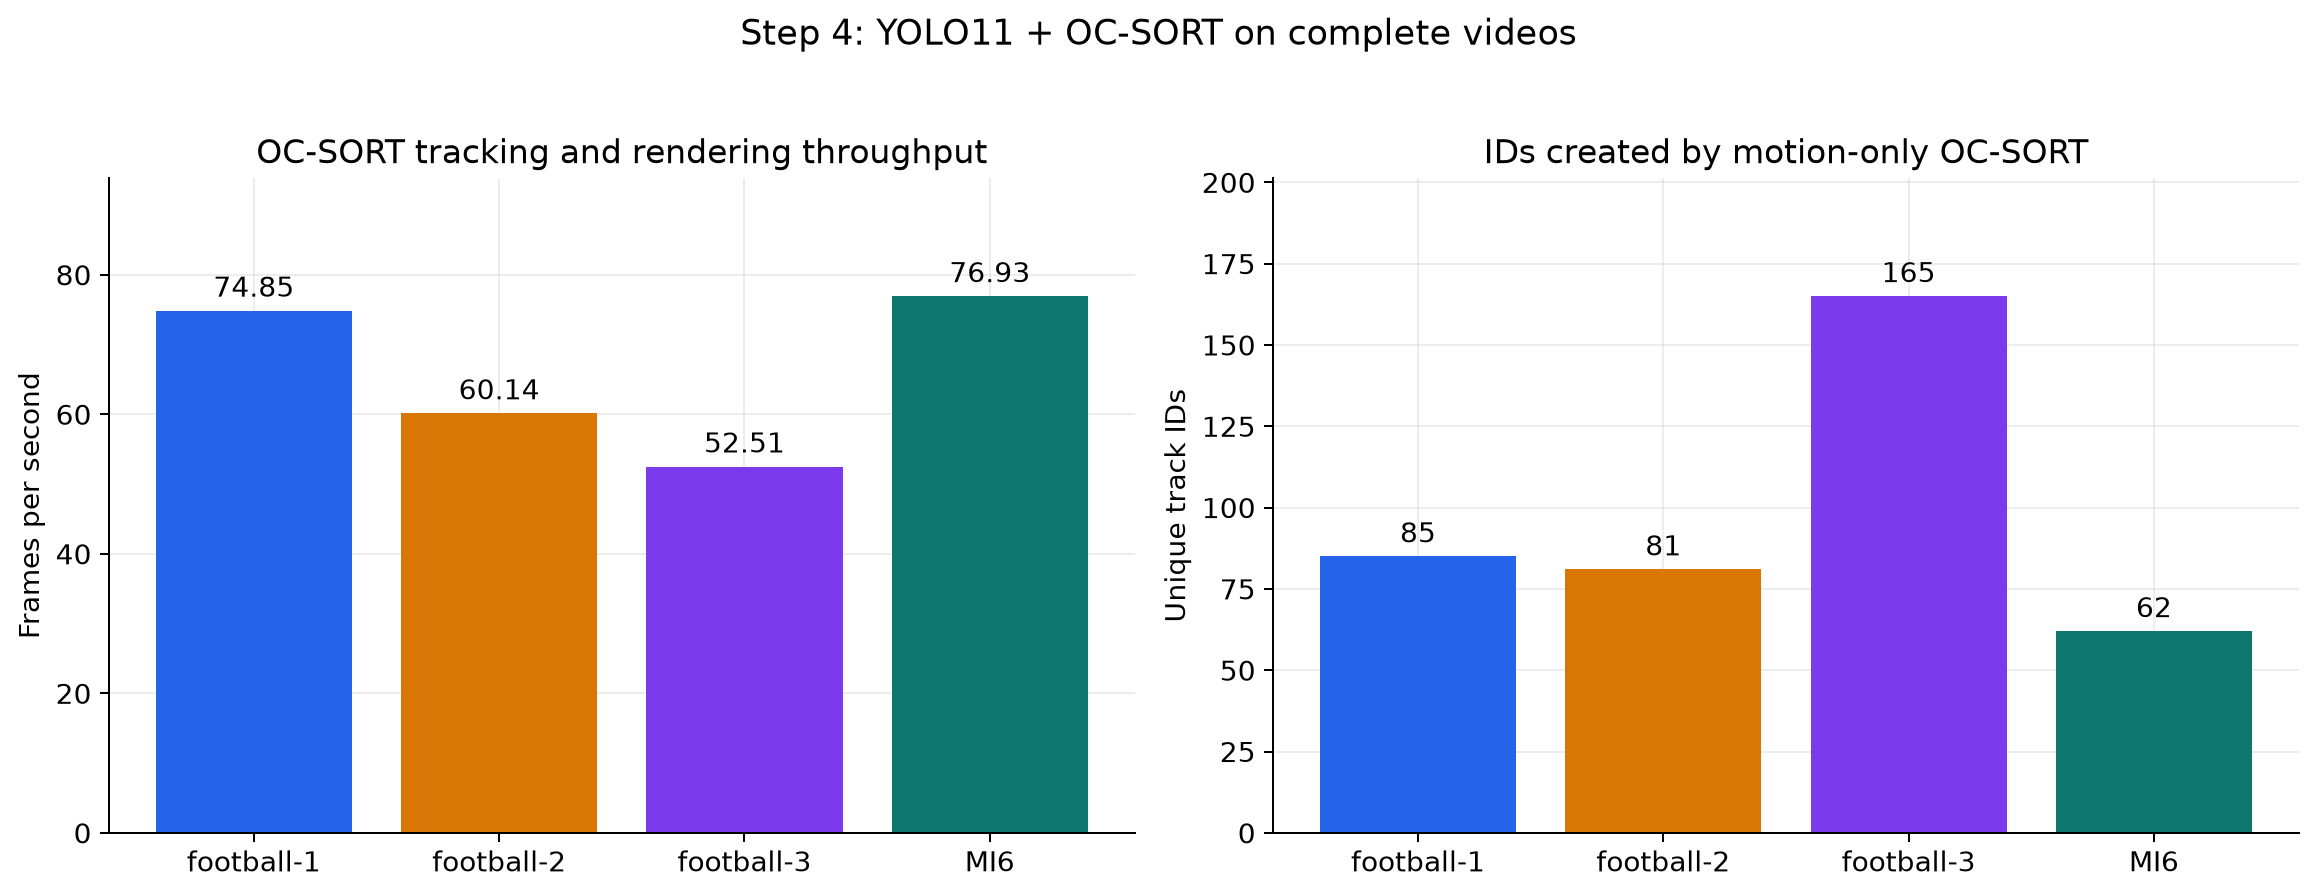

Saved figure: outputs\comparisons\figures\step4_ocsort_summary.png


C:\Users\satya\AppData\Local\Temp\ipykernel_2924\1076759736.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [16]:
ordered_ocsort = ocsort_summary.set_index("video")
figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))
bar_colors = [COLORS[name] for name in ordered_ocsort.index]

fps_bars = axes[0].bar(ordered_ocsort.index, ordered_ocsort["processing_fps"], color=bar_colors)
axes[0].set_title("OC-SORT tracking and rendering throughput")
axes[0].set_ylabel("Frames per second")
axes[0].set_xlabel("")
axes[0].set_ylim(0, max(ordered_ocsort["processing_fps"]) * 1.22)
axes[0].bar_label(fps_bars, fmt="%.2f", padding=3)

id_bars = axes[1].bar(ordered_ocsort.index, ordered_ocsort["unique_global_ids"], color=bar_colors)
axes[1].set_title("IDs created by motion-only OC-SORT")
axes[1].set_ylabel("Unique track IDs")
axes[1].set_xlabel("")
axes[1].set_ylim(0, max(ordered_ocsort["unique_global_ids"]) * 1.22)
axes[1].bar_label(id_bars, fmt="%.0f", padding=3)

figure.suptitle("Step 4: YOLO11 + OC-SORT on complete videos", fontsize=14, y=1.03)
figure.tight_layout()
ocsort_figure_path = FIGURE_ROOT / "step4_ocsort_summary.png"
figure.savefig(ocsort_figure_path, dpi=180, bbox_inches="tight", facecolor="white")
display(Image(filename=str(ocsort_figure_path)))
plt.show()
print(f"Saved figure: {ocsort_figure_path.relative_to(PROJECT_ROOT)}")

In [17]:
from scenecut_tracking.video_gallery import build_video_gallery

gallery_path = build_video_gallery(PROJECT_ROOT)
print(f"Video webpage refreshed: {gallery_path.relative_to(PROJECT_ROOT)}")

Video webpage refreshed: outputs\reports\video_gallery.html


## Takeaways — OC-SORT baseline

- All four initial exports preserve their source frame count and frame rate.
- A 0.25 track-entry gate plus BYTE association removes many short,
  low-confidence tracks compared with archived earlier settings.
- Created-ID count is a fragmentation/noise proxy, not a measured switch
  count. Identity ground truth is required for IDF1, HOTA and true switches.

## Step 5 — YOLO11 + Deep OC-SORT

Deep OC-SORT keeps OC-SORT's observation-centric motion model and adds
pretrained OSNet appearance embeddings plus camera-motion compensation.
The detector remains unchanged.

To make Steps 5 and 6 fast and controlled, OSNet is executed once for every
cached YOLO11 detection. Both Deep OC-SORT methods reuse the same immutable
appearance cache.

In [18]:
from scenecut_tracking.appearance_cache import AppearanceCache, build_appearance_cache
from scenecut_tracking.deep_runner import run_deep_video

APPEARANCE_ROOT = PROJECT_ROOT / CONFIG["experiment"]["appearance_cache_root"]
APPEARANCE_ROOT.mkdir(parents=True, exist_ok=True)
appearance_results: dict[str, dict] = {}
deep_results: dict[str, dict] = {}
cut_results: dict[str, dict] = {}
direct_osnet_results: dict[str, dict] = {}

def build_or_validate_appearance_cache(video_name: str) -> dict:
    video_path = VIDEO_PATHS[video_name]
    detection_path = CACHE_ROOT / f"{video_name}_yolo11n_cpu.npz"
    appearance_path = APPEARANCE_ROOT / f"{video_name}_osnet_x0_25_msmt17_cpu.npz"
    detection_cache = DetectionCache.load(detection_path)

    if appearance_path.exists():
        appearance_cache = AppearanceCache.load(appearance_path)
        action = "validated existing cache"
    else:
        print(f"Extracting OSNet embeddings for every {video_name} detection...")
        appearance_cache = build_appearance_cache(
            video_path=video_path,
            detection_cache_path=detection_path,
            reid_config=CONFIG["reid"],
            project_root=PROJECT_ROOT,
        )
        appearance_cache.save(appearance_path)
        action = "built new cache"

    appearance_cache.validate(detection_cache)
    metadata = appearance_cache.metadata
    result = {
        "video": video_name,
        "status": action,
        "source_frames": metadata["video"]["frame_count"],
        "embedding_rows": metadata["detection_rows"],
        "embedding_width": metadata["embedding_width"],
        "elapsed_seconds": metadata["runtime"]["elapsed_seconds"],
        "appearance_fps": metadata["runtime"]["processing_fps"],
        "cache_path": str(appearance_path.relative_to(PROJECT_ROOT)),
    }
    appearance_results[video_name] = result
    return result

def run_or_validate_deep(video_name: str, mode: str) -> dict:
    if mode not in {"deep_ocsort", "deep_ocsort_osnet", "deep_ocsort_scenecut"}:
        raise ValueError(mode)
    video_path = VIDEO_PATHS[video_name]
    detection_path = CACHE_ROOT / f"{video_name}_yolo11n_cpu.npz"
    appearance_path = APPEARANCE_ROOT / f"{video_name}_osnet_x0_25_msmt17_cpu.npz"
    output_dir = EXPERIMENT_ROOT / video_name / mode
    metrics_path = output_dir / "metrics.json"
    annotated_path = output_dir / "annotated.mp4"
    browser_path = output_dir / "annotated_h264.mp4"

    if metrics_path.exists() and annotated_path.exists() and browser_path.exists():
        metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
        action = "validated existing run"
    else:
        print(f"Running {mode} on every frame of {video_name}...")
        metrics = run_deep_video(
            mode=mode,
            video_path=video_path,
            detection_cache_path=detection_path,
            appearance_cache_path=appearance_path,
            output_dir=output_dir,
            config=CONFIG,
            project_root=PROJECT_ROOT,
        )
        action = "built new run"

    source_meta = inspect_video(video_path)
    annotated_meta = inspect_video(annotated_path)
    browser_meta = inspect_video(browser_path)
    assert metrics["frames"] == source_meta["frames"]
    assert annotated_meta["frames"] == source_meta["frames"]
    assert browser_meta["frames"] == source_meta["frames"]
    assert abs(browser_meta["fps"] - source_meta["fps"]) < 0.01
    assert abs(browser_meta["duration_seconds"] - source_meta["duration_seconds"]) < 0.05

    tracks = pd.read_csv(output_dir / "tracks.csv")
    assert len(tracks) == metrics["track_rows"]
    assert np.isfinite(tracks[["x1", "y1", "x2", "y2"]].to_numpy()).all()

    result = {
        "video": video_name,
        "method": mode,
        "status": action,
        "source_frames": source_meta["frames"],
        "output_frames": browser_meta["frames"],
        "duration_seconds": browser_meta["duration_seconds"],
        "processing_fps": metrics["processing_fps"],
        "elapsed_seconds": metrics["elapsed_seconds"],
        "track_rows": metrics["track_rows"],
        "unique_global_ids": metrics["unique_global_ids"],
        "detected_scene_cuts": metrics["detected_scene_cuts"],
        "accepted_recoveries": metrics["accepted_recoveries"],
        "average_recovery_similarity": metrics["average_recovery_similarity"],
        "finite_track_boxes": True,
        "output_dir": str(output_dir.relative_to(PROJECT_ROOT)),
    }
    if mode == "deep_ocsort":
        deep_results[video_name] = result
    elif mode == "deep_ocsort_scenecut":
        cut_results[video_name] = result
    else:
        direct_osnet_results[video_name] = result
    return result

### Build shared OSNet appearance caches

In [19]:
football_1_appearance = build_or_validate_appearance_cache('football-1')
football_1_appearance

{'video': 'football-1',
 'status': 'validated existing cache',
 'source_frames': 1122,
 'embedding_rows': 8364,
 'embedding_width': 512,
 'elapsed_seconds': 205.97016769999755,
 'appearance_fps': 5.447390816490622,
 'cache_path': 'outputs\\appearance_cache\\football-1_osnet_x0_25_msmt17_cpu.npz'}

In [20]:
football_2_appearance = build_or_validate_appearance_cache('football-2')
football_2_appearance

{'video': 'football-2',
 'status': 'validated existing cache',
 'source_frames': 722,
 'embedding_rows': 6179,
 'embedding_width': 512,
 'elapsed_seconds': 157.30909500000416,
 'appearance_fps': 4.589690125672523,
 'cache_path': 'outputs\\appearance_cache\\football-2_osnet_x0_25_msmt17_cpu.npz'}

In [21]:
football_3_appearance = build_or_validate_appearance_cache('football-3')
football_3_appearance

{'video': 'football-3',
 'status': 'validated existing cache',
 'source_frames': 842,
 'embedding_rows': 13947,
 'embedding_width': 512,
 'elapsed_seconds': 503.1812090000021,
 'appearance_fps': 1.673353426041783,
 'cache_path': 'outputs\\appearance_cache\\football-3_osnet_x0_25_msmt17_cpu.npz'}

In [22]:
mi6_appearance = build_or_validate_appearance_cache('MI6')
mi6_appearance

{'video': 'MI6',
 'status': 'validated existing cache',
 'source_frames': 918,
 'embedding_rows': 4203,
 'embedding_width': 512,
 'elapsed_seconds': 102.56584180000937,
 'appearance_fps': 8.950348224021656,
 'cache_path': 'outputs\\appearance_cache\\MI6_osnet_x0_25_msmt17_cpu.npz'}

In [23]:
appearance_summary = pd.DataFrame(appearance_results.values()).set_index("video").loc[
    ["football-1", "football-2", "football-3", "MI6"]
].reset_index()
assert (appearance_summary["source_frames"] > 0).all()
assert (appearance_summary["embedding_rows"] > 0).all()
assert (appearance_summary["embedding_width"] > 0).all()
display(appearance_summary.style.format({"elapsed_seconds": "{:.2f}", "appearance_fps": "{:.2f}"}))

,video,status,source_frames,embedding_rows,embedding_width,elapsed_seconds,appearance_fps,cache_path
0,football-1,validated existing cache,1122,8364,512,205.97,5.45,outputs\appearance_cache\football-1_osnet_x0_25_msmt17_cpu.npz
1,football-2,validated existing cache,722,6179,512,157.31,4.59,outputs\appearance_cache\football-2_osnet_x0_25_msmt17_cpu.npz
2,football-3,validated existing cache,842,13947,512,503.18,1.67,outputs\appearance_cache\football-3_osnet_x0_25_msmt17_cpu.npz
3,MI6,validated existing cache,918,4203,512,102.57,8.95,outputs\appearance_cache\MI6_osnet_x0_25_msmt17_cpu.npz


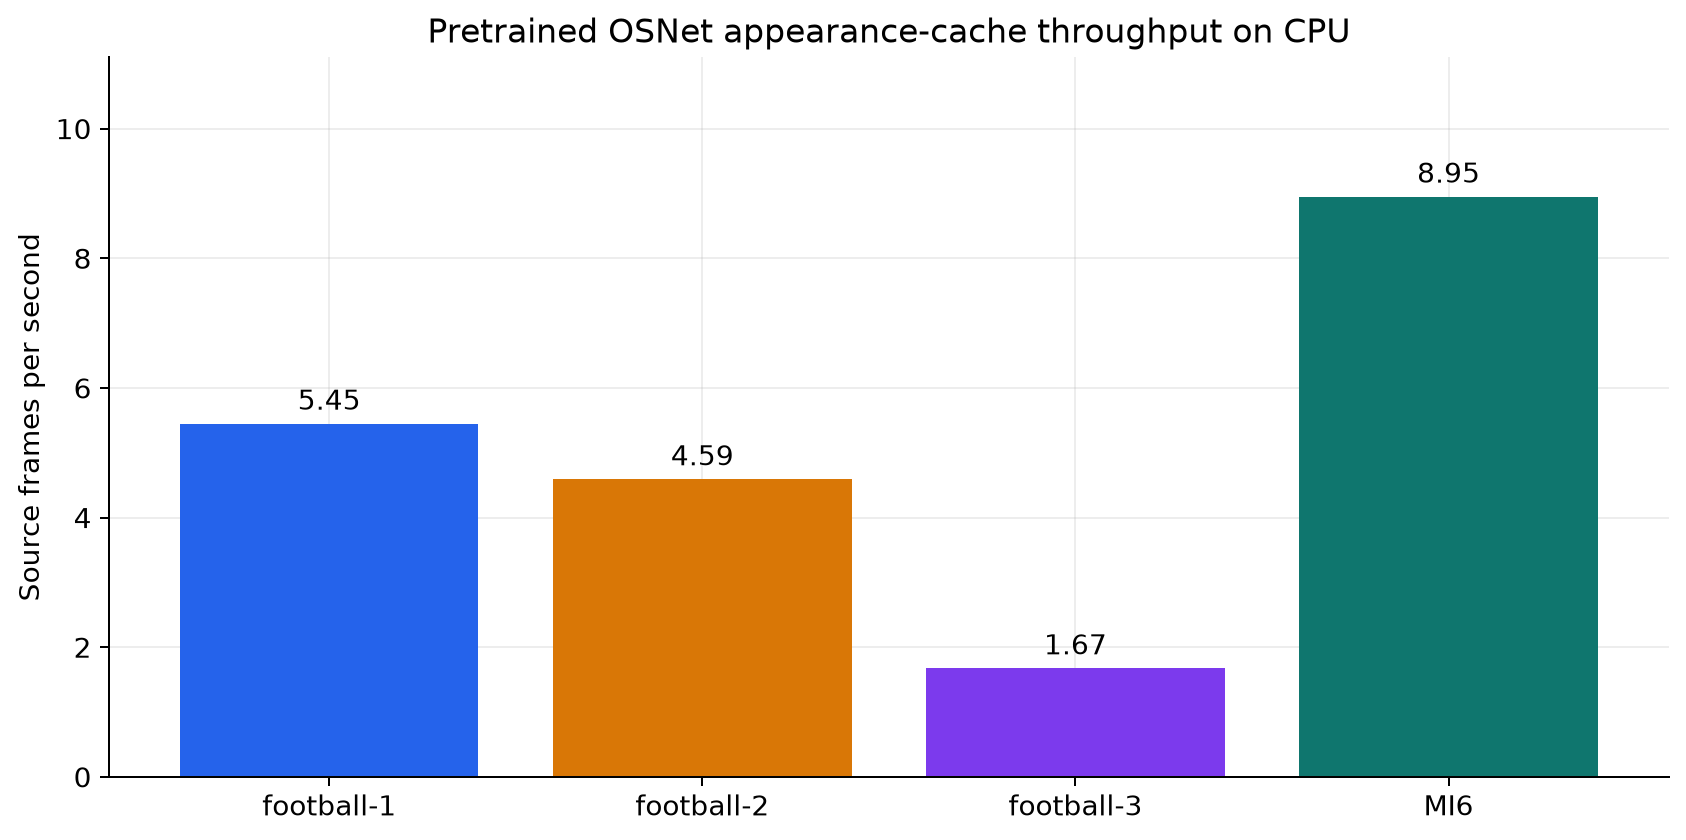

Saved figure: outputs\comparisons\figures\step5_osnet_cache_summary.png


C:\Users\satya\AppData\Local\Temp\ipykernel_2924\589277524.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [24]:
appearance_plot = appearance_summary.set_index("video")
figure, axis = plt.subplots(figsize=(9.5, 4.8))
bars = axis.bar(
    appearance_plot.index,
    appearance_plot["appearance_fps"],
    color=[COLORS[name] for name in appearance_plot.index],
)
axis.set_title("Pretrained OSNet appearance-cache throughput on CPU")
axis.set_ylabel("Source frames per second")
axis.set_xlabel("")
axis.set_ylim(0, max(appearance_plot["appearance_fps"]) * 1.24)
axis.bar_label(bars, fmt="%.2f", padding=3)
figure.tight_layout()
appearance_figure_path = FIGURE_ROOT / "step5_osnet_cache_summary.png"
figure.savefig(appearance_figure_path, dpi=180, bbox_inches="tight", facecolor="white")
display(Image(filename=str(appearance_figure_path)))
plt.show()
print(f"Saved figure: {appearance_figure_path.relative_to(PROJECT_ROOT)}")

### Run Deep OC-SORT on all four videos

In [25]:
football_1_deep = run_or_validate_deep('football-1', 'deep_ocsort')
football_1_deep

{'video': 'football-1',
 'method': 'deep_ocsort',
 'status': 'validated existing run',
 'source_frames': 1122,
 'output_frames': 1122,
 'duration_seconds': 37.4,
 'processing_fps': 52.156090236687206,
 'elapsed_seconds': 21.512348699994618,
 'track_rows': 3705,
 'unique_global_ids': 74,
 'detected_scene_cuts': 0,
 'accepted_recoveries': 0,
 'average_recovery_similarity': None,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\football-1\\deep_ocsort'}

In [26]:
football_2_deep = run_or_validate_deep('football-2', 'deep_ocsort')
football_2_deep

{'video': 'football-2',
 'method': 'deep_ocsort',
 'status': 'validated existing run',
 'source_frames': 722,
 'output_frames': 722,
 'duration_seconds': 24.066666666666666,
 'processing_fps': 44.22376066462626,
 'elapsed_seconds': 16.32606520000263,
 'track_rows': 3121,
 'unique_global_ids': 58,
 'detected_scene_cuts': 0,
 'accepted_recoveries': 0,
 'average_recovery_similarity': None,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\football-2\\deep_ocsort'}

In [27]:
football_3_deep = run_or_validate_deep('football-3', 'deep_ocsort')
football_3_deep

{'video': 'football-3',
 'method': 'deep_ocsort',
 'status': 'validated existing run',
 'source_frames': 842,
 'output_frames': 842,
 'duration_seconds': 28.066666666666666,
 'processing_fps': 39.42857763923808,
 'elapsed_seconds': 21.355069099983666,
 'track_rows': 6512,
 'unique_global_ids': 151,
 'detected_scene_cuts': 0,
 'accepted_recoveries': 0,
 'average_recovery_similarity': None,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\football-3\\deep_ocsort'}

In [28]:
mi6_deep = run_or_validate_deep('MI6', 'deep_ocsort')
mi6_deep

{'video': 'MI6',
 'method': 'deep_ocsort',
 'status': 'validated existing run',
 'source_frames': 918,
 'output_frames': 918,
 'duration_seconds': 30.6,
 'processing_fps': 66.43989577068653,
 'elapsed_seconds': 13.816999400005443,
 'track_rows': 3080,
 'unique_global_ids': 57,
 'detected_scene_cuts': 0,
 'accepted_recoveries': 0,
 'average_recovery_similarity': None,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\MI6\\deep_ocsort'}

In [29]:
deep_summary = pd.DataFrame(deep_results.values()).set_index("video").loc[
    ["football-1", "football-2", "football-3", "MI6"]
].reset_index()
assert (deep_summary["source_frames"] == deep_summary["output_frames"]).all()
assert deep_summary["finite_track_boxes"].all()
display(deep_summary.style.format({"duration_seconds": "{:.2f}", "processing_fps": "{:.2f}", "elapsed_seconds": "{:.2f}"}))
print("PASS: all four Deep OC-SORT videos contain every source frame.")

,video,method,status,source_frames,output_frames,duration_seconds,processing_fps,elapsed_seconds,track_rows,unique_global_ids,detected_scene_cuts,accepted_recoveries,average_recovery_similarity,finite_track_boxes,output_dir
0,football-1,deep_ocsort,validated existing run,1122,1122,37.40,52.16,21.51,3705,74,0,0,None,True,outputs\experiments\football-1\deep_ocsort
1,football-2,deep_ocsort,validated existing run,722,722,24.07,44.22,16.33,3121,58,0,0,None,True,outputs\experiments\football-2\deep_ocsort
2,football-3,deep_ocsort,validated existing run,842,842,28.07,39.43,21.36,6512,151,0,0,None,True,outputs\experiments\football-3\deep_ocsort
3,MI6,deep_ocsort,validated existing run,918,918,30.60,66.44,13.82,3080,57,0,0,None,True,outputs\experiments\MI6\deep_ocsort


PASS: all four Deep OC-SORT videos contain every source frame.


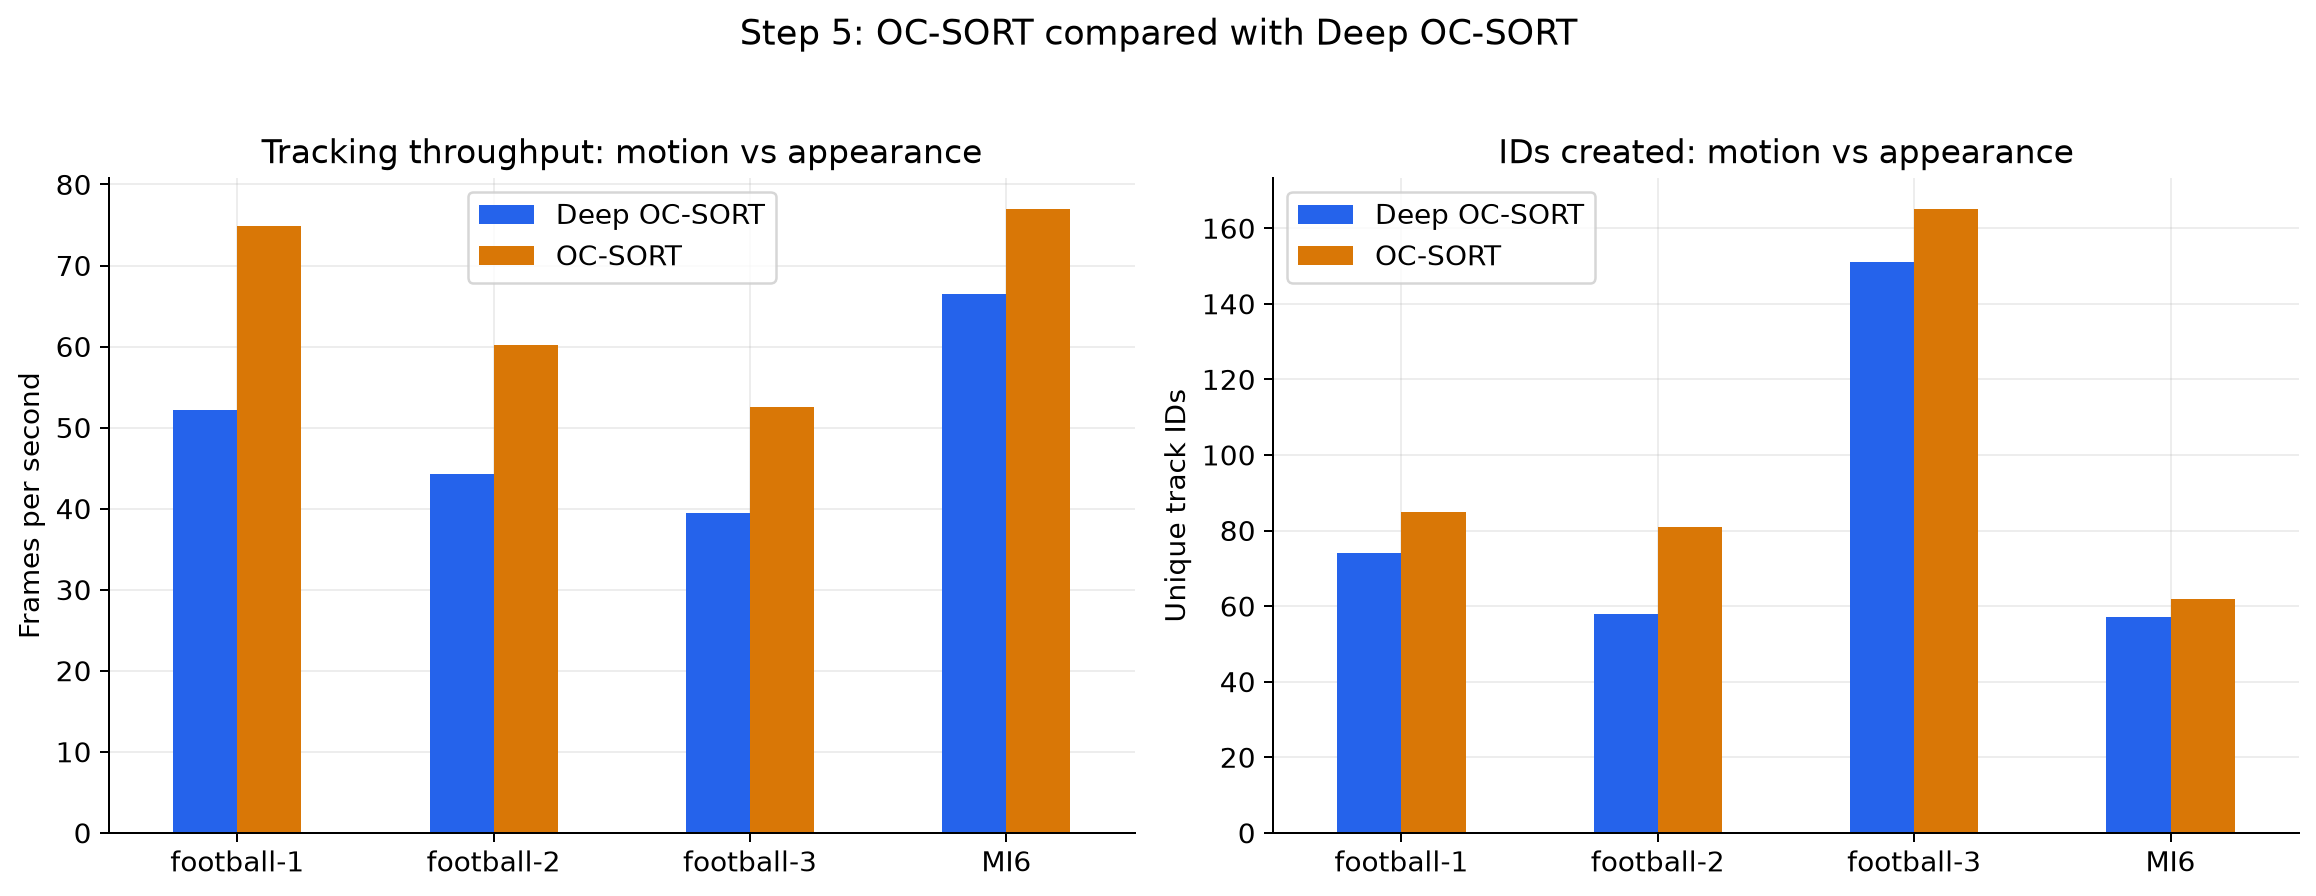

Saved figure: outputs\comparisons\figures\step5_ocsort_vs_deep_ocsort.png


C:\Users\satya\AppData\Local\Temp\ipykernel_2924\2981674261.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [30]:
baseline_for_compare = ocsort_summary[["video", "processing_fps", "unique_global_ids"]].copy()
baseline_for_compare["method_label"] = "OC-SORT"
deep_for_compare = deep_summary[["video", "processing_fps", "unique_global_ids"]].copy()
deep_for_compare["method_label"] = "Deep OC-SORT"
step5_compare = pd.concat([baseline_for_compare, deep_for_compare], ignore_index=True)

figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for index, metric in enumerate(("processing_fps", "unique_global_ids")):
    pivot = step5_compare.pivot(index="video", columns="method_label", values=metric).loc[
        ["football-1", "football-2", "football-3", "MI6"]
    ]
    pivot.plot(kind="bar", ax=axes[index], rot=0, color=["#2563EB", "#D97706"])
    axes[index].set_xlabel("")
    axes[index].legend(title="")
axes[0].set_title("Tracking throughput: motion vs appearance")
axes[0].set_ylabel("Frames per second")
axes[1].set_title("IDs created: motion vs appearance")
axes[1].set_ylabel("Unique track IDs")
figure.suptitle("Step 5: OC-SORT compared with Deep OC-SORT", fontsize=14, y=1.03)
figure.tight_layout()
step5_figure_path = FIGURE_ROOT / "step5_ocsort_vs_deep_ocsort.png"
figure.savefig(step5_figure_path, dpi=180, bbox_inches="tight", facecolor="white")
display(Image(filename=str(step5_figure_path)))
plt.show()
print(f"Saved figure: {step5_figure_path.relative_to(PROJECT_ROOT)}")

## Step 6 — Deep OC-SORT + hard-scene-cut recovery

On each hard cut, active Deep OC-SORT tracks, Kalman state, and camera-motion
history are discarded. The long-term OSNet identity gallery remains. A new
local track receives a previous global ID only when conservative one-to-one
cosine matching exceeds the configured threshold; otherwise it gets a new ID.

In [31]:
football_1_cut = run_or_validate_deep('football-1', 'deep_ocsort_scenecut')
football_1_cut

{'video': 'football-1',
 'method': 'deep_ocsort_scenecut',
 'status': 'validated existing run',
 'source_frames': 1122,
 'output_frames': 1122,
 'duration_seconds': 37.4,
 'processing_fps': 23.135012657441276,
 'elapsed_seconds': 48.49792029999662,
 'track_rows': 3746,
 'unique_global_ids': 77,
 'detected_scene_cuts': 8,
 'accepted_recoveries': 3,
 'average_recovery_similarity': 0.8375864028930664,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\football-1\\deep_ocsort_scenecut'}

In [32]:
football_2_cut = run_or_validate_deep('football-2', 'deep_ocsort_scenecut')
football_2_cut

{'video': 'football-2',
 'method': 'deep_ocsort_scenecut',
 'status': 'validated existing run',
 'source_frames': 722,
 'output_frames': 722,
 'duration_seconds': 24.066666666666666,
 'processing_fps': 17.749551172974062,
 'elapsed_seconds': 40.67708490000223,
 'track_rows': 3142,
 'unique_global_ids': 61,
 'detected_scene_cuts': 4,
 'accepted_recoveries': 6,
 'average_recovery_similarity': 0.8487618863582611,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\football-2\\deep_ocsort_scenecut'}

In [33]:
football_3_cut = run_or_validate_deep('football-3', 'deep_ocsort_scenecut')
football_3_cut

{'video': 'football-3',
 'method': 'deep_ocsort_scenecut',
 'status': 'validated existing run',
 'source_frames': 842,
 'output_frames': 842,
 'duration_seconds': 28.066666666666666,
 'processing_fps': 16.68985929421775,
 'elapsed_seconds': 50.44979620000231,
 'track_rows': 6551,
 'unique_global_ids': 138,
 'detected_scene_cuts': 4,
 'accepted_recoveries': 13,
 'average_recovery_similarity': 0.8204760322204003,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\football-3\\deep_ocsort_scenecut'}

In [34]:
mi6_cut = run_or_validate_deep('MI6', 'deep_ocsort_scenecut')
mi6_cut

{'video': 'MI6',
 'method': 'deep_ocsort_scenecut',
 'status': 'validated existing run',
 'source_frames': 918,
 'output_frames': 918,
 'duration_seconds': 30.6,
 'processing_fps': 26.10809213147046,
 'elapsed_seconds': 35.161512200022116,
 'track_rows': 3149,
 'unique_global_ids': 44,
 'detected_scene_cuts': 8,
 'accepted_recoveries': 17,
 'average_recovery_similarity': 0.8077197565751917,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\MI6\\deep_ocsort_scenecut'}

In [35]:
cut_summary = pd.DataFrame(cut_results.values()).set_index("video").loc[
    ["football-1", "football-2", "football-3", "MI6"]
].reset_index()
assert (cut_summary["source_frames"] == cut_summary["output_frames"]).all()
assert cut_summary["finite_track_boxes"].all()
assert (cut_summary["detected_scene_cuts"] >= 0).all()
display(cut_summary.style.format({
    "duration_seconds": "{:.2f}",
    "processing_fps": "{:.2f}",
    "elapsed_seconds": "{:.2f}",
    "average_recovery_similarity": lambda value: "—" if pd.isna(value) else f"{value:.3f}",
}))
print("PASS: all four cut-aware videos contain every source frame.")

,video,method,status,source_frames,output_frames,duration_seconds,processing_fps,elapsed_seconds,track_rows,unique_global_ids,detected_scene_cuts,accepted_recoveries,average_recovery_similarity,finite_track_boxes,output_dir
0,football-1,deep_ocsort_scenecut,validated existing run,1122,1122,37.40,23.14,48.50,3746,77,8,3,0.838,True,outputs\experiments\football-1\deep_ocsort_scenecut
1,football-2,deep_ocsort_scenecut,validated existing run,722,722,24.07,17.75,40.68,3142,61,4,6,0.849,True,outputs\experiments\football-2\deep_ocsort_scenecut
2,football-3,deep_ocsort_scenecut,validated existing run,842,842,28.07,16.69,50.45,6551,138,4,13,0.820,True,outputs\experiments\football-3\deep_ocsort_scenecut
3,MI6,deep_ocsort_scenecut,validated existing run,918,918,30.60,26.11,35.16,3149,44,8,17,0.808,True,outputs\experiments\MI6\deep_ocsort_scenecut


PASS: all four cut-aware videos contain every source frame.


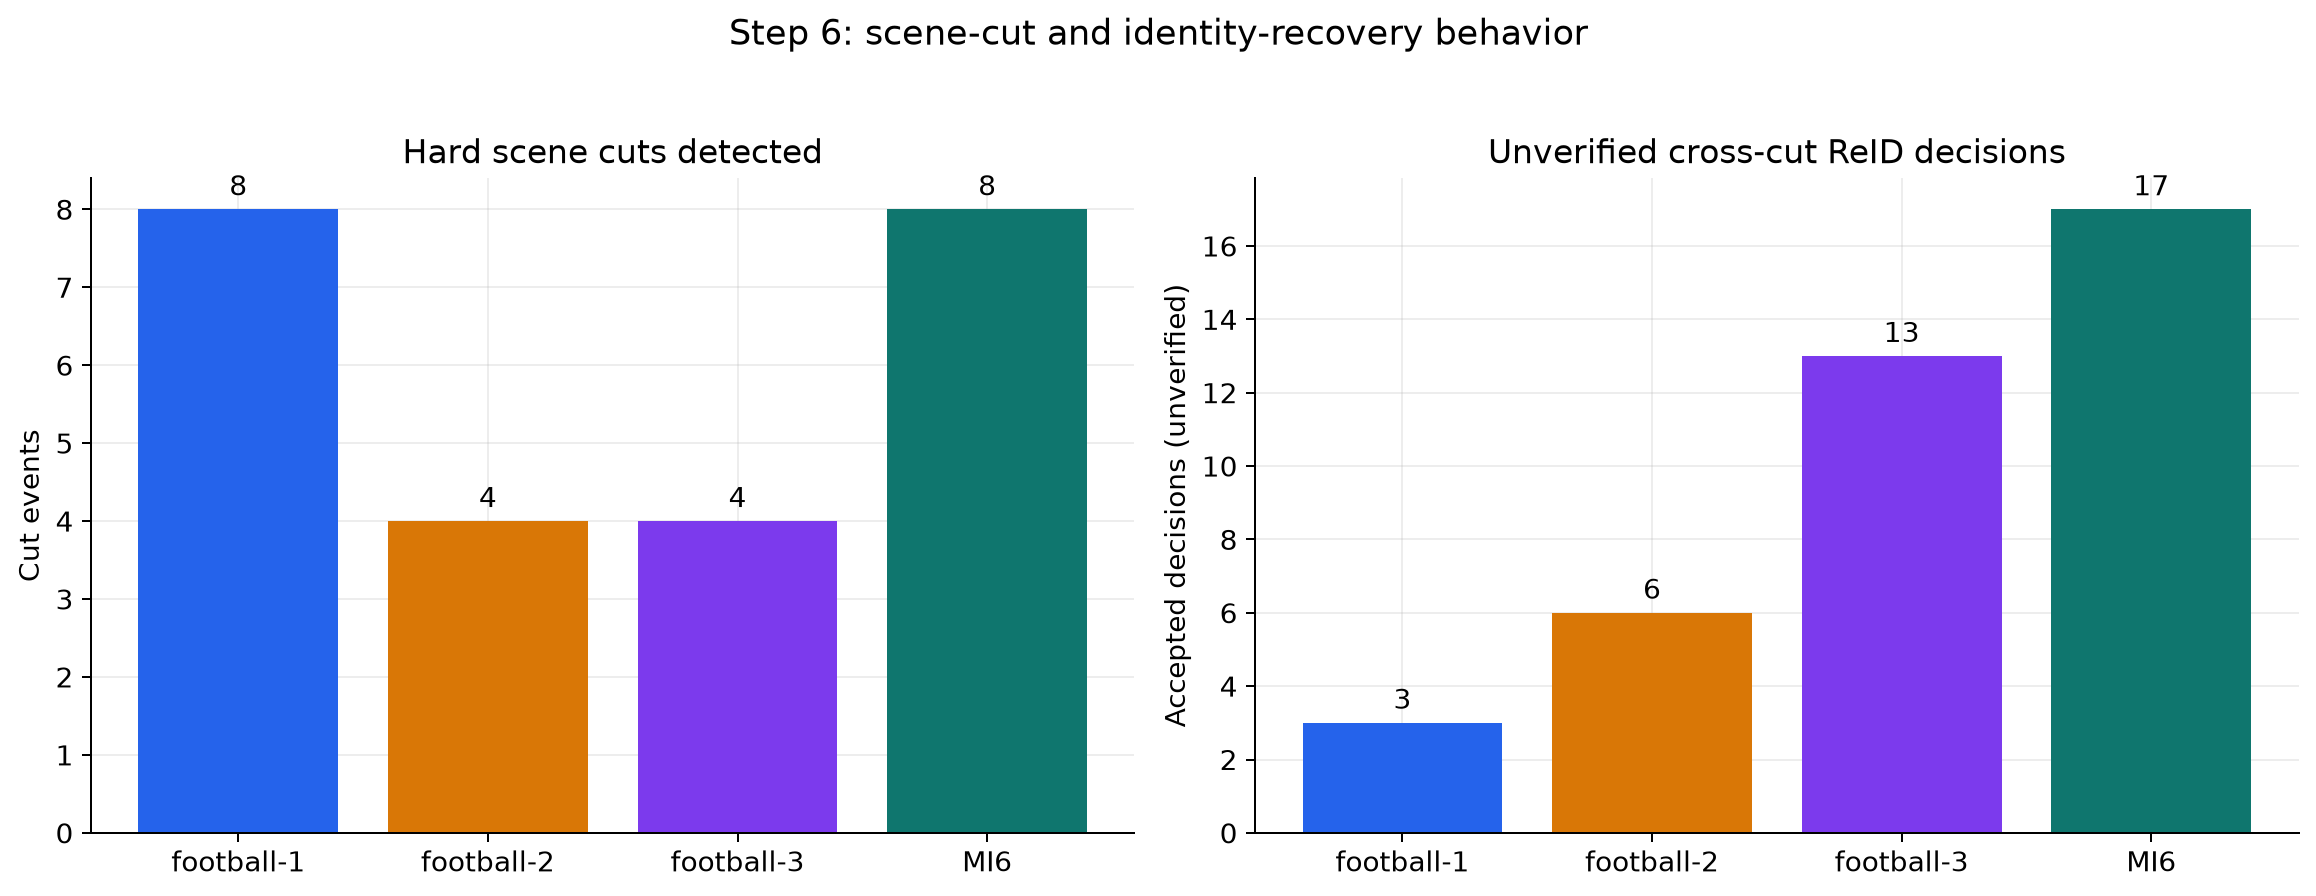

Saved figure: outputs\comparisons\figures\step6_scene_cut_recovery_summary.png


C:\Users\satya\AppData\Local\Temp\ipykernel_2924\400785112.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [36]:
event_plot = cut_summary.set_index("video")
figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))
colors = [COLORS[name] for name in event_plot.index]
cut_bars = axes[0].bar(event_plot.index, event_plot["detected_scene_cuts"], color=colors)
axes[0].set_title("Hard scene cuts detected")
axes[0].set_ylabel("Cut events")
axes[0].set_xlabel("")
axes[0].bar_label(cut_bars, fmt="%.0f", padding=3)
recovery_bars = axes[1].bar(event_plot.index, event_plot["accepted_recoveries"], color=colors)
axes[1].set_title("Unverified cross-cut ReID decisions")
axes[1].set_ylabel("Accepted decisions (unverified)")
axes[1].set_xlabel("")
axes[1].bar_label(recovery_bars, fmt="%.0f", padding=3)
figure.suptitle("Step 6: scene-cut and identity-recovery behavior", fontsize=14, y=1.03)
figure.tight_layout()
event_figure_path = FIGURE_ROOT / "step6_scene_cut_recovery_summary.png"
figure.savefig(event_figure_path, dpi=180, bbox_inches="tight", facecolor="white")
display(Image(filename=str(event_figure_path)))
plt.show()
print(f"Saved figure: {event_figure_path.relative_to(PROJECT_ROOT)}")

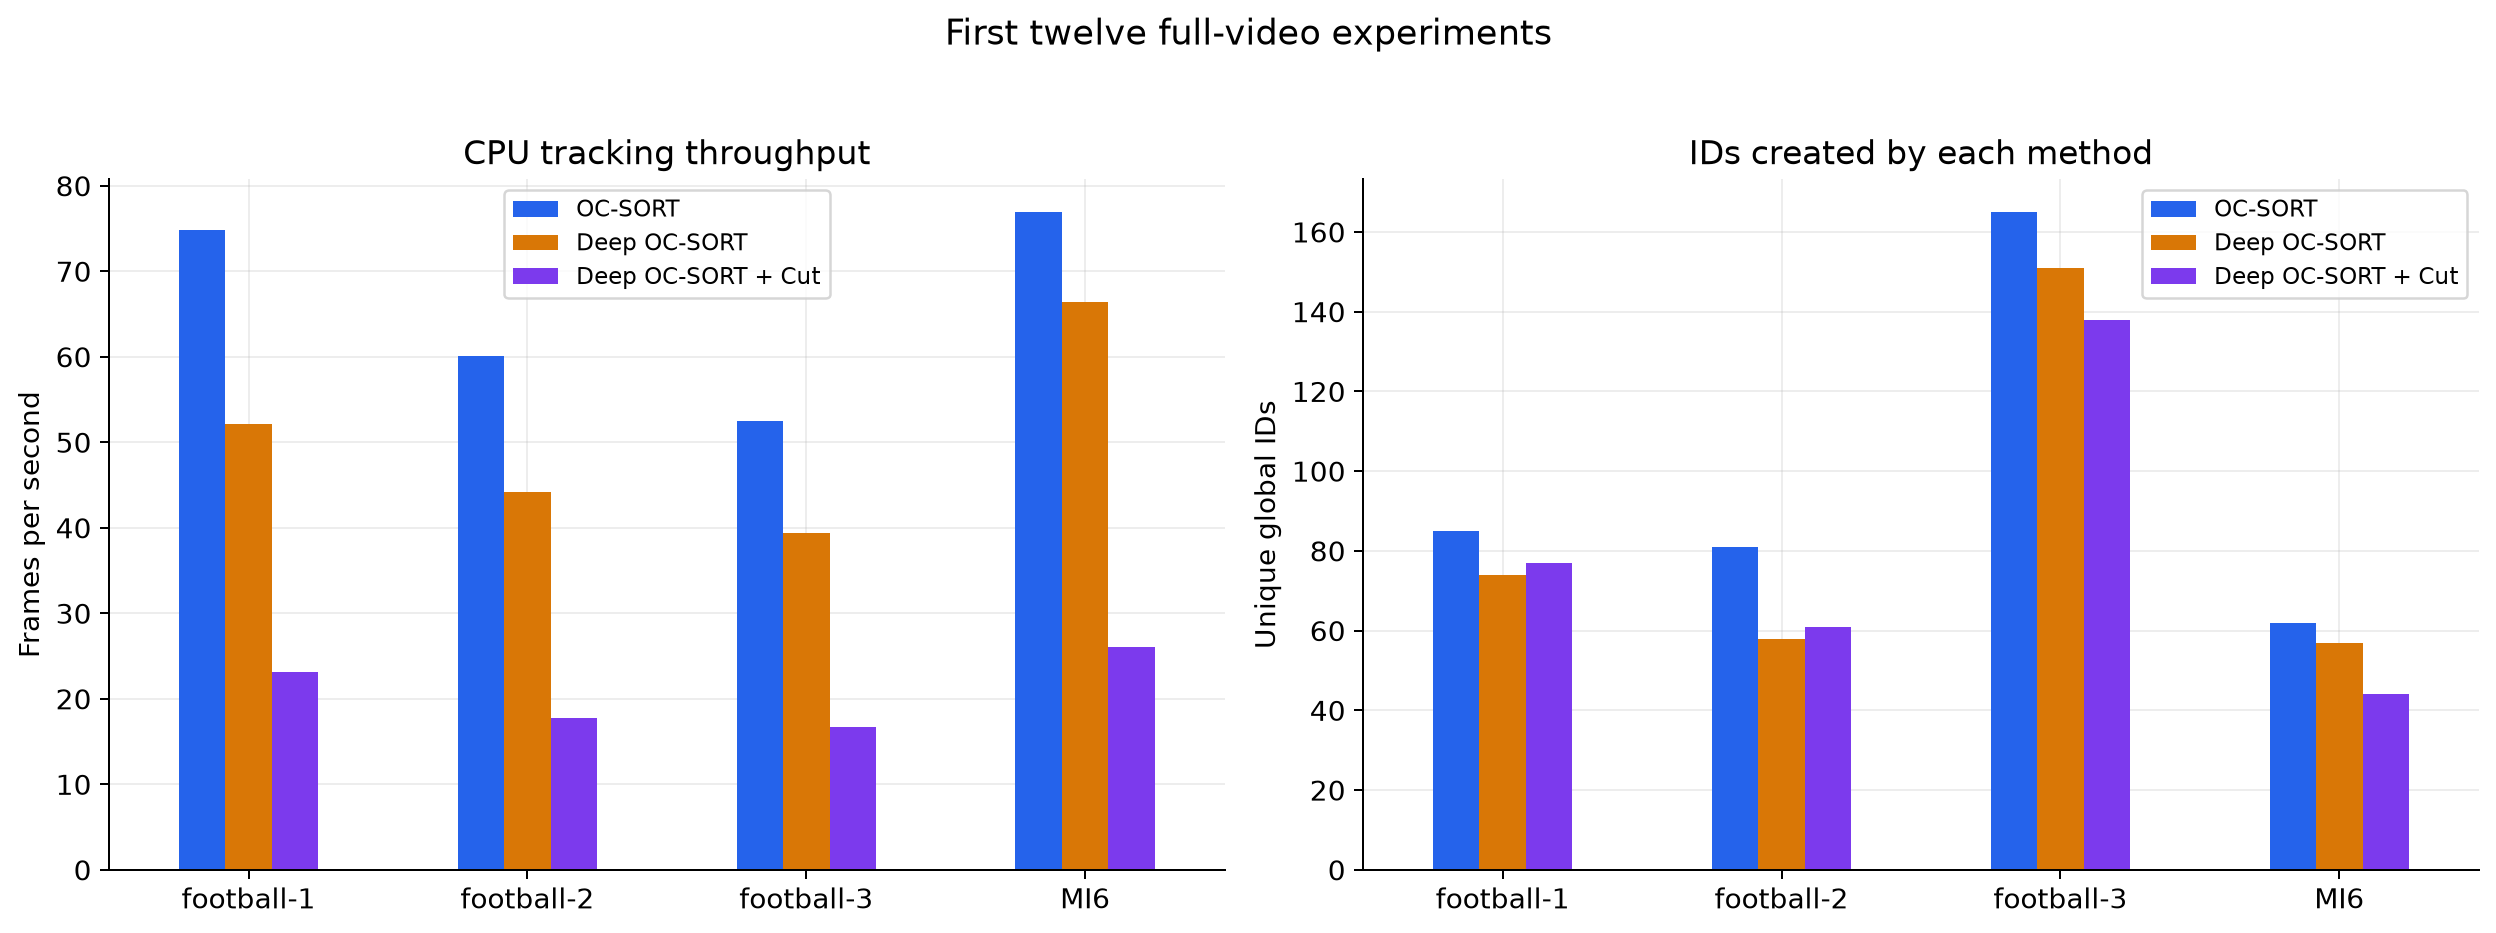

Saved figure: outputs\comparisons\figures\steps4_to_6_all_methods_comparison.png


C:\Users\satya\AppData\Local\Temp\ipykernel_2924\4225167274.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [37]:
all_method_rows = []
for table, method_label in (
    (ocsort_summary, "OC-SORT"),
    (deep_summary, "Deep OC-SORT"),
    (cut_summary, "Deep OC-SORT + Cut"),
):
    selected = table[["video", "processing_fps", "unique_global_ids"]].copy()
    selected["method_label"] = method_label
    all_method_rows.append(selected)
final_comparison = pd.concat(all_method_rows, ignore_index=True)

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
method_colors = ["#2563EB", "#D97706", "#7C3AED"]
for axis, metric, title, ylabel in (
    (axes[0], "processing_fps", "CPU tracking throughput", "Frames per second"),
    (axes[1], "unique_global_ids", "IDs created by each method", "Unique global IDs"),
):
    pivot = final_comparison.pivot(index="video", columns="method_label", values=metric).loc[
        ["football-1", "football-2", "football-3", "MI6"]
    ]
    pivot = pivot[["OC-SORT", "Deep OC-SORT", "Deep OC-SORT + Cut"]]
    pivot.plot(kind="bar", ax=axis, rot=0, color=method_colors)
    axis.set_title(title)
    axis.set_ylabel(ylabel)
    axis.set_xlabel("")
    axis.legend(title="", fontsize=9)
figure.suptitle("First twelve full-video experiments", fontsize=14, y=1.03)
figure.tight_layout()
final_figure_path = FIGURE_ROOT / "steps4_to_6_all_methods_comparison.png"
figure.savefig(final_figure_path, dpi=180, bbox_inches="tight", facecolor="white")
display(Image(filename=str(final_figure_path)))
plt.show()
print(f"Saved figure: {final_figure_path.relative_to(PROJECT_ROOT)}")

In [38]:
gallery_path = build_video_gallery(PROJECT_ROOT)
print(f"Video webpage refreshed: {gallery_path.relative_to(PROJECT_ROOT)}")

Video webpage refreshed: outputs\reports\video_gallery.html


## Takeaways — appearance and cut-aware methods

- Deep OC-SORT adds pretrained OSNet similarity but still requires enough
  box overlap for an association. Appearance weight 1.0 is not pure ReID.
- Guarded cuts reset short-term motion and preserve long-term prototypes.
  Matches within 15 frames after a cut are unverified algorithm decisions.
- The annotated SportsMOT section below supplies actual identity metrics;
  the five custom clips do not have that ground truth.

## Final clip — Joker.mp4

This final pass runs the same three CPU-only methods on every frame of `data/Joker.mp4`. The gallery displays this source as **Final clip**.

In [39]:
# Build the shared YOLO11 detection cache for the final clip.
joker_cache = build_or_validate_cache("Joker")
print(joker_cache)

{'video': 'Joker', 'status': 'validated existing cache', 'source_frames': 551, 'cache_frames': 551, 'detection_rows': 1375, 'elapsed_seconds': 56.450334699999075, 'detector_fps': 9.760792436896022, 'mean_detections_per_frame': 2.49546279491833, 'cache_path': 'outputs\\detection_cache\\Joker_yolo11n_cpu.npz'}


In [40]:
# Build the shared OSNet appearance cache used by Deep OC-SORT and cut-aware recovery.
joker_appearance = build_or_validate_appearance_cache("Joker")
print(joker_appearance)

{'video': 'Joker', 'status': 'validated existing cache', 'source_frames': 551, 'embedding_rows': 1375, 'embedding_width': 512, 'elapsed_seconds': 80.04326729999593, 'appearance_fps': 6.883776969459467, 'cache_path': 'outputs\\appearance_cache\\Joker_osnet_x0_25_msmt17_cpu.npz'}


In [41]:
# Run/validate all three tracking variants on Joker.mp4.
joker_ocsort = run_or_validate_ocsort("Joker")
joker_deep = run_or_validate_deep("Joker", "deep_ocsort")
joker_cut = run_or_validate_deep("Joker", "deep_ocsort_scenecut")

In [42]:
joker_summary = pd.DataFrame([joker_ocsort, joker_deep, joker_cut])
joker_summary = joker_summary[[c for c in ["video", "method", "frames", "duration_seconds", "processing_fps", "unique_global_ids", "detected_scene_cuts", "accepted_recoveries", "mean_recovery_similarity"] if c in joker_summary.columns]]
display(joker_summary.style.format({"duration_seconds":"{:.2f}", "processing_fps":"{:.2f}", "mean_recovery_similarity":"{:.3f}"}, na_rep="—"))

,video,method,duration_seconds,processing_fps,unique_global_ids,detected_scene_cuts,accepted_recoveries
0,Joker,OC-SORT,18.37,67.06,20,—,—
1,Joker,deep_ocsort,18.37,49.99,16,0.000000,0.000000
2,Joker,deep_ocsort_scenecut,18.37,21.90,14,4.000000,3.000000


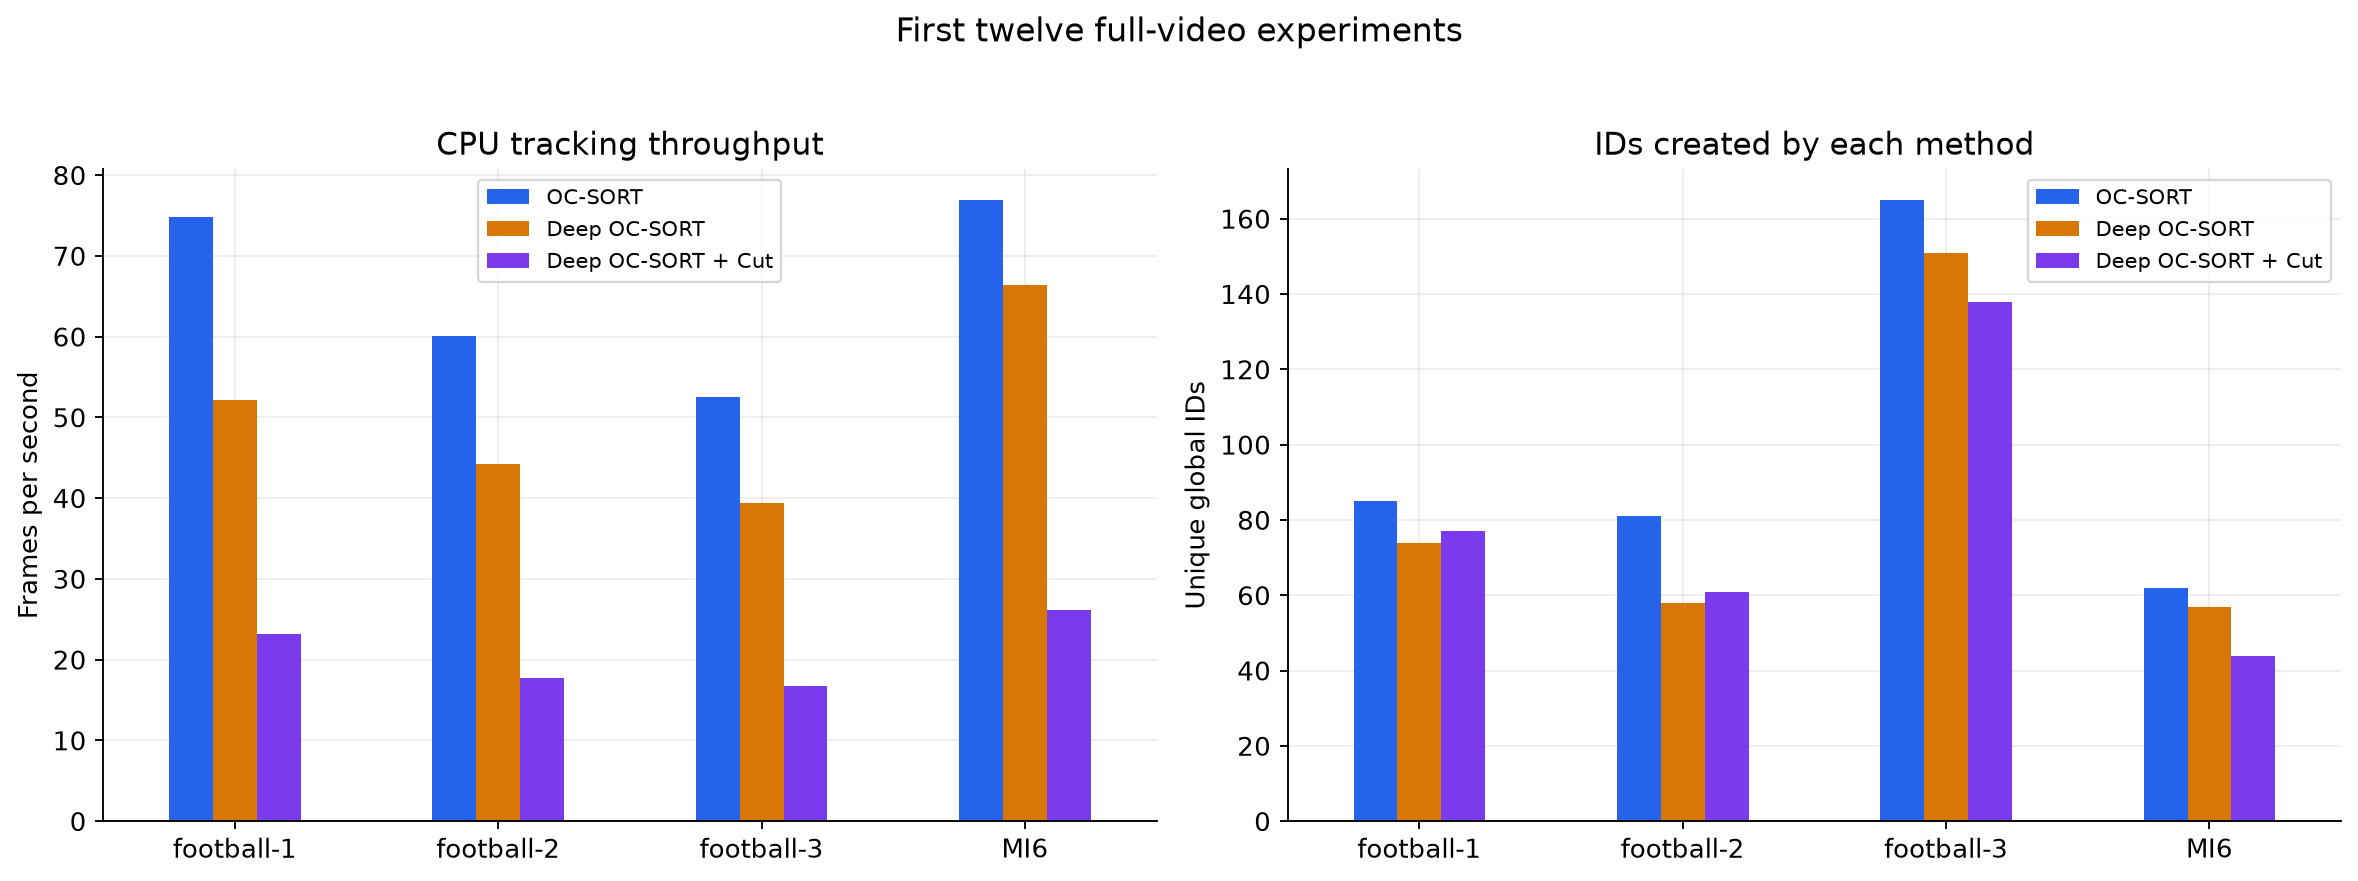

C:\Users\satya\AppData\Local\Temp\ipykernel_2924\1762292444.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
labels = ["OC-SORT", "Deep OC-SORT", "Deep OC-SORT + Cut"]
colors = ["#2563eb", "#0f766e", "#d97706"]
axes[0].bar(labels, joker_summary["processing_fps"], color=colors)
axes[0].set_title("Final clip throughput")
axes[0].set_ylabel("FPS (higher is better)")
axes[0].tick_params(axis="x", rotation=18)
axes[1].bar(labels, joker_summary["unique_global_ids"], color=colors)
axes[1].set_title("Final clip identity count")
axes[1].set_ylabel("Unique IDs (lower is not automatically better)")
axes[1].tick_params(axis="x", rotation=18)
figure.tight_layout()
figure.savefig(FIGURE_ROOT / "joker_three_methods.png", dpi=170, bbox_inches="tight")
display(Image(filename=str(FIGURE_ROOT / "joker_three_methods.png")))
plt.show()

In [44]:
gallery_path = build_video_gallery(PROJECT_ROOT)
print(f"Video webpage refreshed: {gallery_path}")

Video webpage refreshed: D:\Bunker\BaseCamp\ComputerVision\SceneCut Aware tracking\outputs\reports\video_gallery.html


## Fourth column — Deep OC-SORT with OSNet weight 1.0

This is not a separate DeepSORT or plain OC-SORT + OSNet implementation. It
is the same Deep OC-SORT code with appearance weight raised from 0.5 to 1.0
and adaptive weighting disabled. Its IoU gate still applies; there is no
cut reset or long-term identity-memory recovery in this column.

In [45]:
direct_osnet_results = {}
for _video_name in VIDEO_PATHS:
    direct_osnet_results[_video_name] = run_or_validate_deep(_video_name, "deep_ocsort_osnet")
direct_osnet_summary = pd.DataFrame(direct_osnet_results.values()).set_index("video")
display(direct_osnet_summary[["source_frames", "processing_fps", "unique_global_ids", "track_rows"]].style.format({"processing_fps":"{:.2f}"}))

,source_frames,processing_fps,unique_global_ids,track_rows
video,,,,
football-1,1122,51.73,74,3696
football-2,722,44.79,60,3123
football-3,842,38.44,156,6512
MI6,918,69.62,57,3080
Joker,551,47.41,16,714


C:\Users\satya\AppData\Local\Temp\ipykernel_2924\2047711055.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparison_with_osnet = pd.concat([


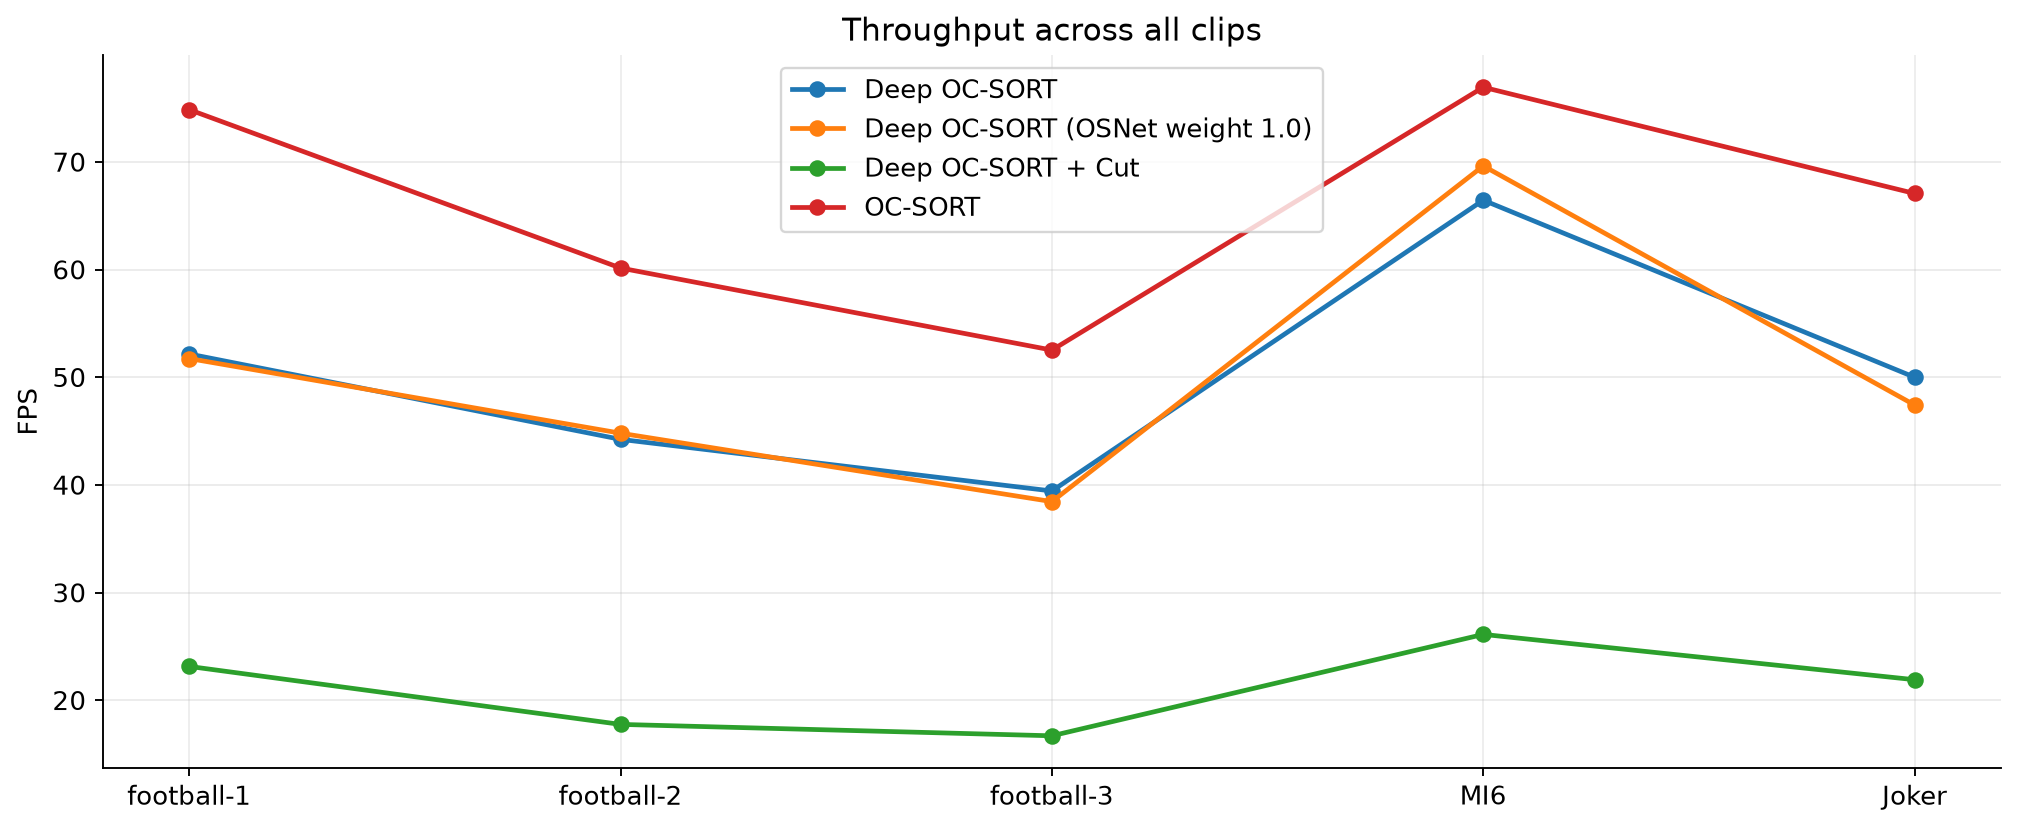

C:\Users\satya\AppData\Local\Temp\ipykernel_2924\2047711055.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [46]:
comparison_with_osnet = pd.concat([
    pd.DataFrame(ocsort_results.values()).assign(method_label="OC-SORT"),
    pd.DataFrame(direct_osnet_results.values()).assign(method_label="Deep OC-SORT (OSNet weight 1.0)"),
    pd.DataFrame(deep_results.values()).assign(method_label="Deep OC-SORT"),
    pd.DataFrame(cut_results.values()).assign(method_label="Deep OC-SORT + Cut"),
], ignore_index=True)
fig, axis = plt.subplots(figsize=(12, 5))
for label, group in comparison_with_osnet.groupby("method_label"):
    axis.plot(group["video"], group["processing_fps"], marker="o", linewidth=2, label=label)
axis.set_title("Throughput across all clips")
axis.set_ylabel("FPS")
axis.legend()
axis.grid(axis="y", alpha=.25)
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "all_four_methods_fps.png", dpi=170, bbox_inches="tight")
display(Image(filename=str(FIGURE_ROOT / "all_four_methods_fps.png")))
plt.show()

In [47]:
gallery_path = build_video_gallery(PROJECT_ROOT)
print(f"Video webpage refreshed with the fourth column: {gallery_path}")

Video webpage refreshed with the fourth column: D:\Bunker\BaseCamp\ComputerVision\SceneCut Aware tracking\outputs\reports\video_gallery.html


## Final diagnosis — annotated benchmark and complete rerun

There are two kinds of evidence here. SportsMOT supplies identity ground
truth, so HOTA, IDF1 and switches are measured. The five custom clips do not.
The benchmark uses one shared YOLO and OSNet cache for every variant.
It is a training-sequence calibration, not a held-out test.

In [48]:
benchmark_path = PROJECT_ROOT / "outputs/benchmarks/sportsmot_calibration/results.json"
benchmark = json.loads(benchmark_path.read_text(encoding="utf-8"))
variant_names = [
    ("OC-SORT", "ocsort_old", "ocsort_tuned"),
    ("Deep OC-SORT", "deep_ocsort_old", "deep_ocsort_tuned"),
    ("Deep OC-SORT, OSNet weight 1.0", "deep_direct_old", "deep_direct_tuned"),
]
benchmark_rows = []
for label, old_key, tuned_key in variant_names:
    for setting, key in (("old", old_key), ("tuned", tuned_key)):
        scores = benchmark["variants"][key]
        benchmark_rows.append({
            "method": label, "setting": setting,
            "HOTA": scores["HOTA"], "IDF1": scores["IDF1"],
            "ID switches": scores["IDs"], "FP": scores["FP"],
            "tracker-only FPS": scores["tracker_processing_fps"],
        })
benchmark_table = pd.DataFrame(benchmark_rows)
display(benchmark_table.style.format({
    "HOTA": "{:.2f}", "IDF1": "{:.2f}", "tracker-only FPS": "{:.2f}",
}))
print("Ground truth: SportsMOT TRAIN example, 875 frames; not a held-out score.")
print("Detector AP50:", round(benchmark["detector"]["AP50"], 2))

,method,setting,HOTA,IDF1,ID switches,FP,tracker-only FPS
0,OC-SORT,old,33.66,29.22,421,3564,45.88
1,OC-SORT,tuned,43.66,42.83,262,2218,74.62
2,Deep OC-SORT,old,38.74,33.50,381,3716,34.16
3,Deep OC-SORT,tuned,50.52,50.39,169,1318,42.76
4,"Deep OC-SORT, OSNet weight 1.0",old,38.78,35.23,354,3758,35.38
5,"Deep OC-SORT, OSNet weight 1.0",tuned,51.25,51.13,150,1317,51.05


Ground truth: SportsMOT TRAIN example, 875 frames; not a held-out score.
Detector AP50: 87.31


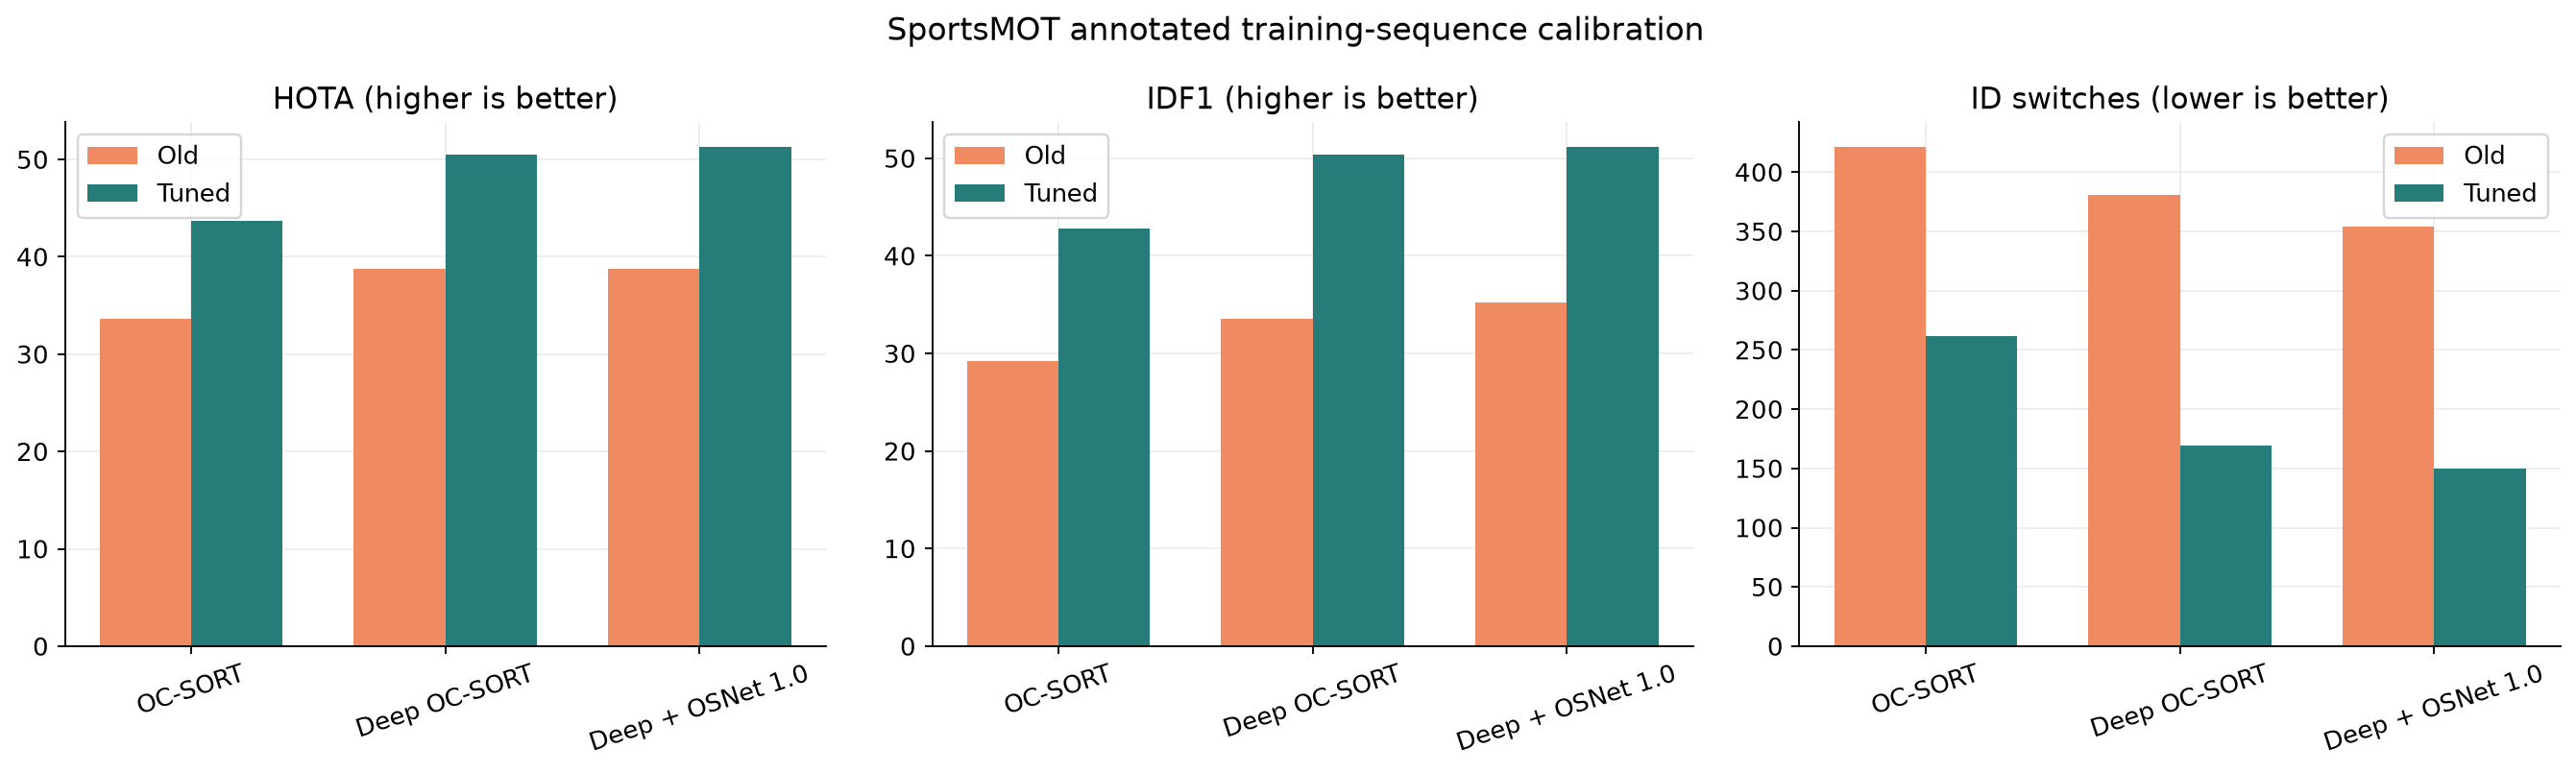

C:\Users\satya\AppData\Local\Temp\ipykernel_2924\2621161634.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [49]:
figure, axes = plt.subplots(1, 3, figsize=(16, 4.8))
method_labels = [row[0] for row in variant_names]
x_positions = np.arange(len(method_labels))
for axis, metric in zip(axes, ("HOTA", "IDF1", "ID switches")):
    key = "IDs" if metric == "ID switches" else metric
    old_values = [benchmark["variants"][old_key][key] for _, old_key, _ in variant_names]
    tuned_values = [benchmark["variants"][new_key][key] for _, _, new_key in variant_names]
    axis.bar(x_positions - 0.18, old_values, width=0.36, label="Old", color="#ef8a62")
    axis.bar(x_positions + 0.18, tuned_values, width=0.36, label="Tuned", color="#267c78")
    axis.set_xticks(x_positions, ["OC-SORT", "Deep OC-SORT", "Deep + OSNet 1.0"], rotation=18)
    axis.set_title(metric + (" (lower is better)" if metric == "ID switches" else " (higher is better)"))
    axis.legend()
figure.suptitle("SportsMOT annotated training-sequence calibration", fontsize=14)
figure.tight_layout()
figure.savefig(FIGURE_ROOT / "sportsmot_calibration.png", dpi=170, bbox_inches="tight")
display(Image(filename=str(FIGURE_ROOT / "sportsmot_calibration.png")))
plt.show()

### Five custom clips — fragmentation and cut diagnostics

Fewer created IDs may indicate less fragmentation or fewer tracked people;
it is not proof of accuracy. Accepted ReID decisions are not verified
correct matches. MI6 detection cache was rebuilt during project relocation,
so its old/new row is not an isolated tracker-only ablation.

In [50]:
archived_root = PROJECT_ROOT / "outputs/archive_previous/before_2026-09-24_diagnosis"
method_names = {
    "ocsort": "OC-SORT",
    "deep_ocsort": "Deep OC-SORT",
    "deep_ocsort_osnet": "Deep + OSNet weight 1.0",
    "deep_ocsort_scenecut": "Deep + guarded cuts",
}
diagnostic_rows = []
for video_name in VIDEO_PATHS:
    for method_key, method_label in method_names.items():
        old_file = archived_root / video_name / method_key / "metrics.json"
        new_file = EXPERIMENT_ROOT / video_name / method_key / "metrics.json"
        old_metrics = json.loads(old_file.read_text(encoding="utf-8"))
        new_metrics = json.loads(new_file.read_text(encoding="utf-8"))
        assert old_metrics["frames"] == new_metrics["frames"]
        diagnostic_rows.append({
            "video": video_name, "method": method_label,
            "frames": new_metrics["frames"],
            "old IDs (proxy)": old_metrics["unique_global_ids"],
            "new IDs (proxy)": new_metrics["unique_global_ids"],
            "old cuts": old_metrics["detected_scene_cuts"],
            "new cuts": new_metrics["detected_scene_cuts"],
            "old ReID decisions": old_metrics["accepted_recoveries"],
            "new ReID decisions": new_metrics["accepted_recoveries"],
            "tracker/render FPS": new_metrics["processing_fps"],
        })
diagnostics = pd.DataFrame(diagnostic_rows)
assert len(diagnostics) == 20
display(diagnostics.style.format({"tracker/render FPS": "{:.2f}"}))
print("All 20 outputs exist. IDs, cuts and ReID decisions are NOT accuracy scores.")

,video,method,frames,old IDs (proxy),new IDs (proxy),old cuts,new cuts,old ReID decisions,new ReID decisions,tracker/render FPS
0,football-1,OC-SORT,1122,216,85,0,0,0,0,74.85
1,football-1,Deep OC-SORT,1122,209,74,0,0,0,0,52.16
2,football-1,Deep + OSNet weight 1.0,1122,212,74,0,0,0,0,51.73
3,football-1,Deep + guarded cuts,1122,226,77,11,8,27,3,23.14
4,football-2,OC-SORT,722,194,81,0,0,0,0,60.14
5,football-2,Deep OC-SORT,722,181,58,0,0,0,0,44.22
6,football-2,Deep + OSNet weight 1.0,722,185,60,0,0,0,0,44.79
7,football-2,Deep + guarded cuts,722,195,61,18,4,110,6,17.75
8,football-3,OC-SORT,842,457,165,0,0,0,0,52.51
9,football-3,Deep OC-SORT,842,395,151,0,0,0,0,39.43


All 20 outputs exist. IDs, cuts and ReID decisions are NOT accuracy scores.


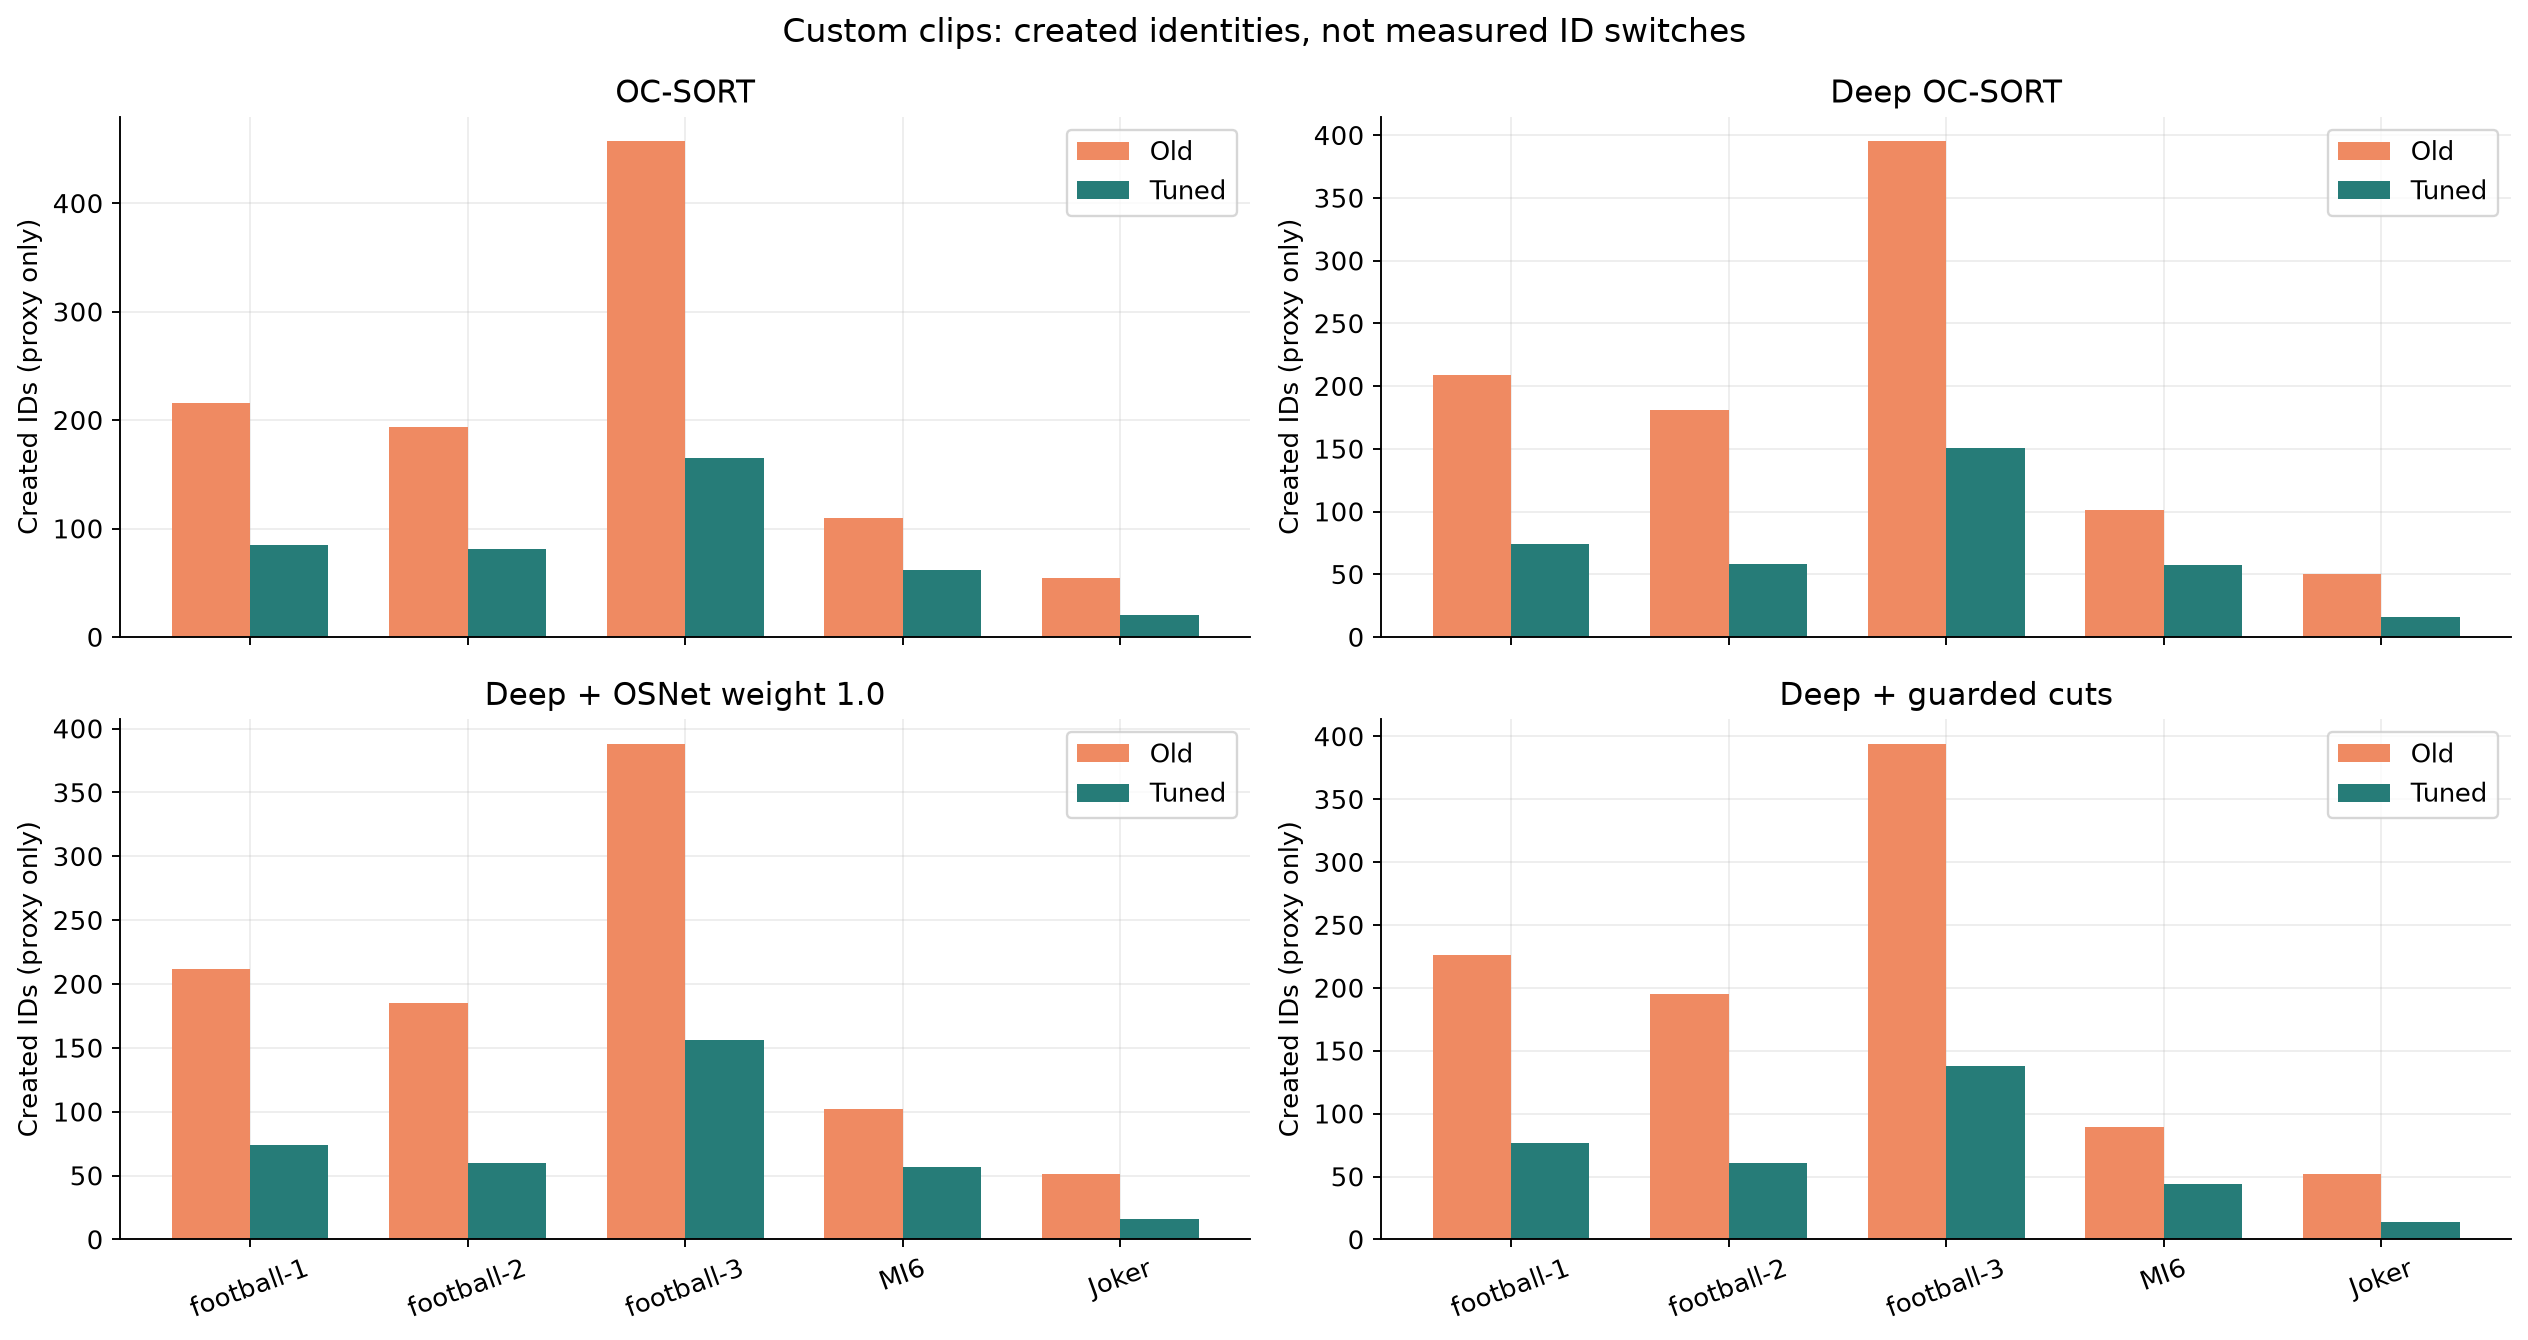

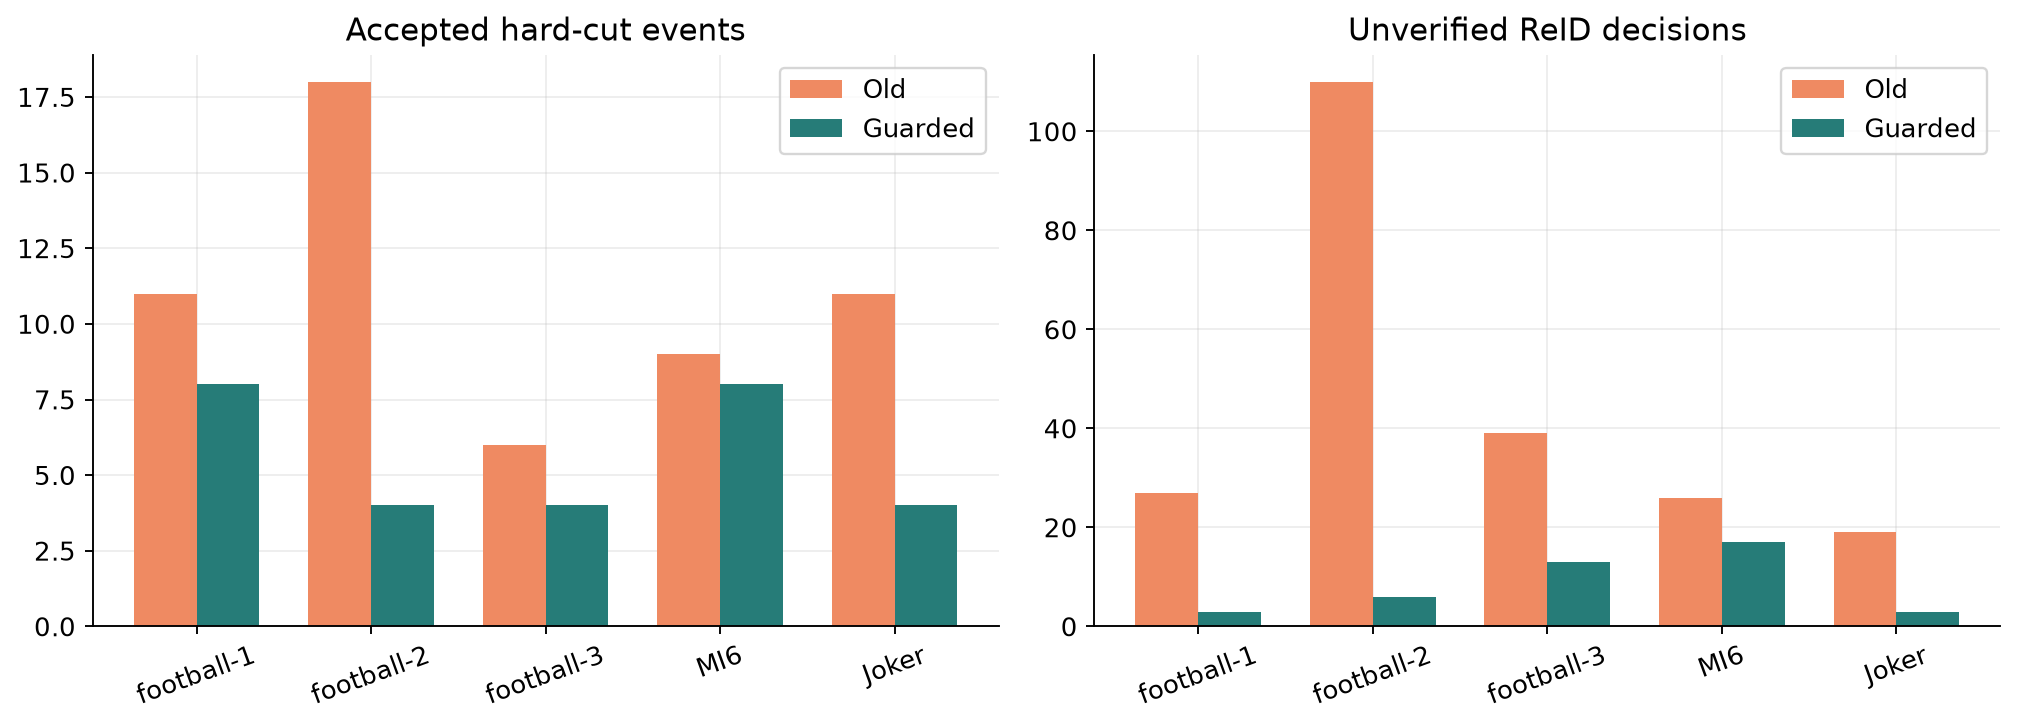

In [51]:
figure, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
for axis, (method_key, method_label) in zip(axes.flat, method_names.items()):
    subset = diagnostics[diagnostics["method"] == method_label]
    x_positions = np.arange(len(subset))
    axis.bar(x_positions - 0.18, subset["old IDs (proxy)"], 0.36, label="Old", color="#ef8a62")
    axis.bar(x_positions + 0.18, subset["new IDs (proxy)"], 0.36, label="Tuned", color="#267c78")
    axis.set_xticks(x_positions, subset["video"], rotation=20)
    axis.set_title(method_label)
    axis.set_ylabel("Created IDs (proxy only)")
    axis.legend()
figure.suptitle("Custom clips: created identities, not measured ID switches", fontsize=14)
figure.tight_layout()
figure.savefig(FIGURE_ROOT / "custom_created_ids_proxy.png", dpi=170, bbox_inches="tight")
display(Image(filename=str(FIGURE_ROOT / "custom_created_ids_proxy.png")))
# plot already saved

cut_rows = diagnostics[diagnostics["method"] == "Deep + guarded cuts"]
figure, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for axis, old_column, new_column, title in (
    (axes[0], "old cuts", "new cuts", "Accepted hard-cut events"),
    (axes[1], "old ReID decisions", "new ReID decisions", "Unverified ReID decisions"),
):
    x_positions = np.arange(len(cut_rows))
    axis.bar(x_positions - 0.18, cut_rows[old_column], 0.36, label="Old", color="#ef8a62")
    axis.bar(x_positions + 0.18, cut_rows[new_column], 0.36, label="Guarded", color="#267c78")
    axis.set_xticks(x_positions, cut_rows["video"], rotation=20)
    axis.set_title(title)
    axis.legend()
figure.tight_layout()
figure.savefig(FIGURE_ROOT / "cut_guard_diagnostics.png", dpi=170, bbox_inches="tight")
display(Image(filename=str(FIGURE_ROOT / "cut_guard_diagnostics.png")))
# plot already saved

### Interpretation and reproduction

The strongest supported improvement is calibrated track admission on the
annotated football sequence. The cut guard removes many false resets, but
cross-cut ReID correctness on the custom clips remains unmeasured. Deep
OC-SORT's IoU gate still explains same-shot ID loss; boxes remain limited
by YOLO detection and occlusion.

Root-cause report: docs/TRACKING_DIAGNOSIS.md
Video gallery: outputs/reports/video_gallery.html

From the project root, rerun experiments with
.\.venv\Scripts\python.exe scriptsun_all_experiments.py
and verify with
.\.venv\Scripts\python.exe scriptsalidate_outputs.py
and
.\.venv\Scripts\python.exe scriptsenchmark_sportsmot.py